# Calderon's Problem Dirichlet-to-Neumann (DtN) map data-pair generation

Given an underlying true conductivity $\gamma(x)$ in the 2D square domain: $x\in \Omega \equiv[0,1]\times [0,1]$, this code generates randomized compositions of wavelets (see below) as Dirichlet BCs $f$ at the boundary of the domain $\partial \Omega$ and solves the direct Calderon problem with a finite differences method.
$$     \left\{ \begin{array}{l}
     \nabla\cdot\left(\gamma(x)\,\nabla u(x)\right) = 0 \\ \\
     u(x)|_{\partial\Omega} = f \ .
    \end{array}\right.  $$

This is an elliptic PDE with Dirichlet BCs. Once the solution $u(x)$ is obtained, one can then define a measurement performed on the boundary which maps an electric potential $f\in H^{1/2}(\partial\Omega)$ to an electric current $J  \in H^{-1/2}(\partial \Omega)$. This map from $f$ to $J$ is known as the Dirichlet-to-Neumann (DtN) map (or voltage-to-current map) and we denote it $\Lambda_\gamma$ so that:
$$\Lambda_\gamma(f) = \left[ \gamma(x)\frac{\partial u}{\partial \hat{n}} \right]_{\partial\Omega}\equiv J \,\,,$$
where $\hat{n}$ represents the unit outer normal vector to $\partial\Omega$.

This process can be repeated for multiple Dirichlet BCs $f_k$ ($k=1, \dots, K$), solving with ffd for each $k$, and obtain the corresponding Neumman BCs $J_k$. These pairs ${f_k,J_k}_{k=1}^K$ will be the DtN data-points used for the PINN-based reconstruction of the conductivity $\gamma(x)$.

Note that, for the FFD solver, $\gamma(x)$ is defined on an $N\times N$ spatial, uniformly sampled grid.

## Direct problem - forward finite differences solver

In [1]:
# filename: codebase/fdm_forward_solver.py
import os
import time
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set plotting style
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
mpl.rcParams['text.usetex'] = False

### Generate the data - Construct the true conducitvity $\gamma(x,y)$

In [2]:
class FDMForwardSolver:
    """
    A Finite Difference Method (FDM) solver for the 2D Calderon's problem.

    This class solves the elliptic PDE nabla . (gamma * nabla u) = 0 on a
    square domain [0, 1] x [0, 1] with Dirichlet boundary conditions.
    """

    def __init__(self, N):
        """
        Initializes the FDM solver.

        Args:
            N (int): The number of grid points in each dimension.
        """
        self.N = N
        self.h = 1.0 / (N - 1)
        self.x = np.linspace(0, 1, N)
        self.y = np.linspace(0, 1, N)
        self.xx, self.yy = np.meshgrid(self.x, self.y)
        self.boundary_info = self.get_boundary_info()

    def get_boundary_info(self):
        """
        Identifies boundary nodes, coordinates, and normal vectors.

        Returns:
            dict: A dictionary containing:
                'indices': 1D indices of boundary nodes.
                'coords': (x, y) coordinates of boundary nodes.
                'normals': (nx, ny) normal vectors for each boundary node.
        """
        indices = []
        coords = []
        normals = []
        is_boundary = np.zeros((self.N, self.N), dtype=bool)

        for i in range(self.N):
            for j in range(self.N):
                is_bnd = False
                normal = [0, 0]
                if i == 0:  # Bottom
                    is_bnd = True
                    normal[1] = -1.0
                if i == self.N - 1:  # Top
                    is_bnd = True
                    normal[1] = 1.0
                if j == 0:  # Left
                    is_bnd = True
                    normal[0] = -1.0
                if j == self.N - 1:  # Right
                    is_bnd = True
                    normal[0] = 1.0

                if is_bnd:
                    idx_1d = i * self.N + j
                    indices.append(idx_1d)
                    coords.append((self.x[j], self.y[i]))
                    # Normalize the normal vector in case of corners
                    norm_len = np.sqrt(normal[0]**2 + normal[1]**2)
                    normals.append((normal[0]/norm_len, normal[1]/norm_len))
                    is_boundary[i, j] = True

        # Ensure unique nodes for corners
        unique_indices, unique_idx_map = np.unique(indices, return_index=True)
        
        return {
            'indices': unique_indices,
            'coords': np.array(coords)[unique_idx_map],
            'normals': np.array(normals)[unique_idx_map],
            'mask': is_boundary
        }


    def _assemble_system(self, gamma):
        """
        Assembles the sparse matrix A for the linear system Au=b.

        Args:
            gamma (np.ndarray): A N x N array of conductivity values.

        Returns:
            scipy.sparse.csc_matrix: The assembled sparse matrix A.
        """
        num_nodes = self.N * self.N
        A = sp.lil_matrix((num_nodes, num_nodes))
        h2 = self.h * self.h

        for i in range(1, self.N - 1):
            for j in range(1, self.N - 1):
                p = i * self.N + j

                # Harmonic mean for conductivity at interfaces
                gamma_E = 2 * gamma[i, j] * gamma[i, j + 1] / (gamma[i, j] + gamma[i, j + 1])
                gamma_W = 2 * gamma[i, j] * gamma[i, j - 1] / (gamma[i, j] + gamma[i, j - 1])
                gamma_N = 2 * gamma[i, j] * gamma[i + 1, j] / (gamma[i, j] + gamma[i + 1, j])
                gamma_S = 2 * gamma[i, j] * gamma[i - 1, j] / (gamma[i, j] + gamma[i - 1, j])

                A[p, p] = -(gamma_E + gamma_W + gamma_N + gamma_S) / h2
                A[p, p + 1] = gamma_E / h2  # East
                A[p, p - 1] = gamma_W / h2  # West
                A[p, p + self.N] = gamma_N / h2  # North
                A[p, p - self.N] = gamma_S / h2  # South

        return A.tocsc()

    def solve(self, gamma, boundary_values):
        """
        Solves the forward problem for a given gamma and boundary conditions.

        Args:
            gamma (np.ndarray): The N x N conductivity map.
            boundary_values (dict): A dictionary mapping 1D boundary indices
                                    to potential values.

        Returns:
            np.ndarray: A N x N array of the potential u.
        """
        num_nodes = self.N * self.N
        A = self._assemble_system(gamma)
        b = np.zeros(num_nodes)

        # Apply Dirichlet boundary conditions
        for idx, val in boundary_values.items():
            A[idx, :] = 0
            A[idx, idx] = 1
            b[idx] = val

        u_flat = spsolve(A, b)
        return u_flat.reshape((self.N, self.N))

    def compute_normal_current(self, u, gamma):
        """
        Computes the normal current density J = gamma * du/dn on the boundary.

        Args:
            u (np.ndarray): The N x N potential field.
            gamma (np.ndarray): The N x N conductivity map.

        Returns:
            np.ndarray: A 1D array of normal current densities at boundary points.
        """
        bnd_indices = self.boundary_info['indices']
        bnd_normals = self.boundary_info['normals']
        bnd_coords_map = {tuple(self.boundary_info['coords'][i]): i for i in range(len(bnd_indices))}
        
        J = np.zeros(len(bnd_indices))
        
        for i in range(self.N):
            for j in range(self.N):
                if not self.boundary_info['mask'][i, j]:
                    continue

                coord_tuple = (self.x[j], self.y[i])
                if coord_tuple not in bnd_coords_map:
                    continue
                
                map_idx = bnd_coords_map[coord_tuple]
                nx, ny = bnd_normals[map_idx]
                
                # Compute gradients using second-order one-sided differences
                du_dx = 0.0
                du_dy = 0.0

                # Gradient in x
                if j == 0:  # Left boundary, forward difference
                    du_dx = (-3 * u[i, 0] + 4 * u[i, 1] - u[i, 2]) / (2 * self.h)
                elif j == self.N - 1:  # Right boundary, backward difference
                    du_dx = (3 * u[i, -1] - 4 * u[i, -2] + u[i, -3]) / (2 * self.h)
                else: # Interior point for x-gradient (corners on y-boundary)
                    du_dx = (u[i, j + 1] - u[i, j - 1]) / (2 * self.h)

                # Gradient in y
                if i == 0:  # Bottom boundary, forward difference
                    du_dy = (-3 * u[0, j] + 4 * u[1, j] - u[2, j]) / (2 * self.h)
                elif i == self.N - 1:  # Top boundary, backward difference
                    du_dy = (3 * u[-1, j] - 4 * u[-2, j] + u[-3, j]) / (2 * self.h)
                else: # Interior point for y-gradient (corners on x-boundary)
                    du_dy = (u[i + 1, j] - u[i - 1, j]) / (2 * self.h)

                du_dn = du_dx * nx + du_dy * ny
                J[map_idx] = gamma[i, j] * du_dn
                
        return J


def get_gamma_single_inclusion(N):
    """Generates a conductivity map with a single circular inclusion."""
    gamma = np.ones((N, N))
    center_x, center_y, radius = 0.5, 0.5, 0.2
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
    mask = (xx - center_x)**2 + (yy - center_y)**2 < radius**2
    gamma[mask] = 2.0
    return gamma

def get_gamma_gaussian(N):
    """Generates a conductivity map with a 2D Gaussian inclusion."""
    gamma = np.ones((N, N))
    center_x, center_y, radius = 0.5, 0.5, 0.3
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
    
    sigma = radius
    gaussian = np.exp(-((xx - center_x)**2 + (yy - center_y)**2) / (2 * sigma**2))
    
    # Scale so that max = 2.0 (background=1, peak=2)
    gamma += gaussian  # background 1 + bump [0..1]
    
    return gamma

def get_gamma_radial_sine(N, freq=5, amplitude=1.0):
    """
    Generates a radially symmetric conductivity map with sine variation.
    
    Parameters
    ----------
    N : int
        Grid size (N x N).
    freq : float
        Frequency of the sine oscillation in radial direction.
    amplitude : float
        Amplitude of oscillation.
    """
    gamma = np.ones((N, N))
    center_x, center_y = 0.5, 0.5
    
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
    
    r = np.sqrt((xx - center_x)**2 + (yy - center_y)**2)
    
    gamma += amplitude * np.sin(2 * np.pi * freq * r)
    
    return gamma


def get_gamma_multiple_inclusions(N):
    """Generates a conductivity map with two circular inclusions."""
    gamma = np.ones((N, N))
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
    mask1 = (xx - 0.3)**2 + (yy - 0.6)**2 < 0.15**2
    gamma[mask1] = 2.0
    mask2 = (xx - 0.7)**2 + (yy - 0.3)**2 < 0.2**2
    gamma[mask2] = 0.5
    return gamma

def get_gamma_checkerboard(N):
    """Generates a checkerboard conductivity map."""
    gamma = np.ones((N, N))
    x = np.linspace(0, 1, N, endpoint = False)
    y = np.linspace(0, 1, N, endpoint = False)
    xx, yy = np.meshgrid(x, y)
    checker = (np.floor(xx * 4) + np.floor(yy * 4)) % 2
    gamma[checker == 1] = 2.0
    return gamma


import numpy as np

def get_gamma_smooth_checkerboard(N, m=4, n=4, L=1.0, A=0.5):
    """
    Generates a smooth 'checkerboard-like' conductivity map using sinusoidal modulation:
        gamma(x, y) = 1 + A * sin(m * pi * x / L) * cos(n * pi * y / L)

    Parameters
    ----------
    N : int
        Grid size (NxN)
    m : int
        Frequency of the sinusoid along x (number of horizontal oscillations)
    n : int
        Frequency of the sinusoid along y (number of vertical oscillations)
    L : float
        Domain length (default: 1.0)
    A : float
        Amplitude of modulation (default: 1.0)

    Returns
    -------
    gamma : ndarray of shape (N, N)
        Smooth checkerboard conductivity map
    """
    x = np.linspace(0, L, N)
    y = np.linspace(0, L, N)
    xx, yy = np.meshgrid(x, y, indexing='ij')

    gamma = 1.5 + A * np.sin(m * np.pi * xx / L) * np.cos(n *np.pi * yy / L + (n/L)*np.pi/8)
    return gamma






### Define the forward solver

In [3]:
class FDMForwardSolver:
    """
    A Finite Difference Method (FDM) solver for the 2D Calderon's problem.

    This class solves the elliptic PDE nabla . (gamma * nabla u) = 0 on a
    square domain [0, 1] x [0, 1] with Dirichlet boundary conditions.
    """

    def __init__(self, N):
        """
        Initializes the FDM solver.

        Args:
            N (int): The number of grid points in each dimension.
        """
        self.N = N
        self.h = 1.0 / (N - 1)
        self.x = np.linspace(0, 1, N)
        self.y = np.linspace(0, 1, N)
        self.xx, self.yy = np.meshgrid(self.x, self.y)
        self.boundary_info = self.get_boundary_info()

    def get_boundary_info(self):
        """
        Identifies boundary nodes, coordinates, and normal vectors.

        Returns:
            dict: A dictionary containing:
                'indices': 1D indices of boundary nodes.
                'coords': (x, y) coordinates of boundary nodes.
                'normals': (nx, ny) normal vectors for each boundary node.
        """
        indices = []
        coords = []
        normals = []
        is_boundary = np.zeros((self.N, self.N), dtype=bool)

        for i in range(self.N):
            for j in range(self.N):
                is_bnd = False
                normal = [0, 0]
                if i == 0:  # Bottom
                    is_bnd = True
                    normal[1] = -1.0
                if i == self.N - 1:  # Top
                    is_bnd = True
                    normal[1] = 1.0
                if j == 0:  # Left
                    is_bnd = True
                    normal[0] = -1.0
                if j == self.N - 1:  # Right
                    is_bnd = True
                    normal[0] = 1.0

                if is_bnd:
                    idx_1d = i * self.N + j
                    indices.append(idx_1d)
                    coords.append((self.x[j], self.y[i]))
                    # Normalize the normal vector in case of corners
                    norm_len = np.sqrt(normal[0]**2 + normal[1]**2)
                    normals.append((normal[0]/norm_len, normal[1]/norm_len))
                    is_boundary[i, j] = True

        # Ensure unique nodes for corners
        unique_indices, unique_idx_map = np.unique(indices, return_index=True)
       
        return {
            'indices': unique_indices,
            'coords': np.array(coords)[unique_idx_map],
            'normals': np.array(normals)[unique_idx_map],
            'mask': is_boundary
        }


    def _assemble_system(self, gamma):
        """
        Assembles the sparse matrix A for the linear system Au=b.

        Args:
            gamma (np.ndarray): A N x N array of conductivity values.

        Returns:
            scipy.sparse.csc_matrix: The assembled sparse matrix A.
        """
        num_nodes = self.N * self.N
        A = sp.lil_matrix((num_nodes, num_nodes))
        h2 = self.h * self.h

        for i in range(1, self.N - 1):
            for j in range(1, self.N - 1):
                p = i * self.N + j

                # Harmonic mean for conductivity at interfaces
                gamma_E = 2 * gamma[i, j] * gamma[i, j + 1] / (gamma[i, j] + gamma[i, j + 1])
                gamma_W = 2 * gamma[i, j] * gamma[i, j - 1] / (gamma[i, j] + gamma[i, j - 1])
                gamma_N = 2 * gamma[i, j] * gamma[i + 1, j] / (gamma[i, j] + gamma[i + 1, j])
                gamma_S = 2 * gamma[i, j] * gamma[i - 1, j] / (gamma[i, j] + gamma[i - 1, j])

                A[p, p] = -(gamma_E + gamma_W + gamma_N + gamma_S) / h2
                A[p, p + 1] = gamma_E / h2  # East
                A[p, p - 1] = gamma_W / h2  # West
                A[p, p + self.N] = gamma_N / h2  # North
                A[p, p - self.N] = gamma_S / h2  # South

        return A.tocsc()

    def solve(self, gamma, boundary_values):
        """
        Solves the forward problem for a given gamma and boundary conditions.

        Args:
            gamma (np.ndarray): The N x N conductivity map.
            boundary_values (dict): A dictionary mapping 1D boundary indices
                                    to potential values.

        Returns:
            np.ndarray: A N x N array of the potential u.
        """
        num_nodes = self.N * self.N
        A = self._assemble_system(gamma)
        b = np.zeros(num_nodes)

        # Apply Dirichlet boundary conditions
        for idx, val in boundary_values.items():
            A[idx, :] = 0
            A[idx, idx] = 1
            b[idx] = val

        u_flat = spsolve(A, b)
        return u_flat.reshape((self.N, self.N))

    def compute_normal_current(self, u, gamma):
        """
        Computes the normal current density J = gamma * du/dn on the boundary.

        Args:
            u (np.ndarray): The N x N potential field.
            gamma (np.ndarray): The N x N conductivity map.

        Returns:
            np.ndarray: A 1D array of normal current densities at boundary points.
        """
        bnd_indices = self.boundary_info['indices']
        bnd_normals = self.boundary_info['normals']
        bnd_coords_map = {tuple(self.boundary_info['coords'][i]): i for i in range(len(bnd_indices))}
       
        J = np.zeros(len(bnd_indices))
       
        for i in range(self.N):
            for j in range(self.N):
                if not self.boundary_info['mask'][i, j]:
                    continue

                coord_tuple = (self.x[j], self.y[i])
                if coord_tuple not in bnd_coords_map:
                    continue
               
                map_idx = bnd_coords_map[coord_tuple]
                nx, ny = bnd_normals[map_idx]
               
                # Compute gradients using second-order one-sided differences
                du_dx = 0.0
                du_dy = 0.0

                # Gradient in x
                if j == 0:  # Left boundary, forward difference
                    du_dx = (-3 * u[i, 0] + 4 * u[i, 1] - u[i, 2]) / (2 * self.h)
                elif j == self.N - 1:  # Right boundary, backward difference
                    du_dx = (3 * u[i, -1] - 4 * u[i, -2] + u[i, -3]) / (2 * self.h)
                else: # Interior point for x-gradient (corners on y-boundary)
                    du_dx = (u[i, j + 1] - u[i, j - 1]) / (2 * self.h)

                # Gradient in y
                if i == 0:  # Bottom boundary, forward difference
                    du_dy = (-3 * u[0, j] + 4 * u[1, j] - u[2, j]) / (2 * self.h)
                elif i == self.N - 1:  # Top boundary, backward difference
                    du_dy = (3 * u[-1, j] - 4 * u[-2, j] + u[-3, j]) / (2 * self.h)
                else: # Interior point for y-gradient (corners on x-boundary)
                    du_dy = (u[i + 1, j] - u[i - 1, j]) / (2 * self.h)

                du_dn = du_dx * nx + du_dy * ny
                J[map_idx] = gamma[i, j] * du_dn
               
        return J




### Define functions to generate different types of profiles for the ground truth conductivity $\gamma(x,y)$

In [13]:
def get_gamma_single_inclusion(N, R = 0.2):
    """Generates a conductivity map with a single circular inclusion."""
    gamma = np.ones((N, N))
    center_x, center_y, radius = 0.5, 0.5, R
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
    mask = (xx - center_x)**2 + (yy - center_y)**2 < radius**2
    gamma[mask] = 2.0
    return gamma



def get_gamma_two_inclusions(N):
    """
    Two non-overlapping circular inclusions:
    - Inclusion 1 at center (0.5, 0.5), radius 0.2
    - Inclusion 2 shifted to (0.8, 0.2), radius 0.15
    """
    gamma = np.full((N, N), 0.75)  #or np.ones((N, N))*0.75

    # Circle parameters
    cx1, cy1, r1, val1 = 0.5, 0.5, 0.2, 1.5
    cx2, cy2, r2, val2 = 0.8, 0.2, 0.15, 2.25

    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)

    mask1 = (xx - cx1)**2 + (yy - cy1)**2 < r1**2
    mask2 = (xx - cx2)**2 + (yy - cy2)**2 < r2**2

    gamma[mask1] = val1
    gamma[mask2] = val2

    return gamma




def get_gamma_gaussian(N):
    """Generates a conductivity map with a 2D Gaussian inclusion."""
    gamma = np.ones((N, N))
    center_x, center_y, radius = 0.5, 0.5, 0.3
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
   
    sigma = radius
    gaussian = np.exp(-((xx - center_x)**2 + (yy - center_y)**2) / (2 * sigma**2))
   
    # Scale so that max = 2.0 (background=1, peak=2)
    gamma += gaussian  # background 1 + bump [0..1]
   
    return gamma




def get_gamma_radial_sine(N, freq=5, amplitude=1.0):
    """
    Generates a radially symmetric conductivity map with sine variation.
   
    Parameters
    ----------
    N : int
        Grid size (N x N).
    freq : float
        Frequency of the sine oscillation in radial direction.
    amplitude : float
        Amplitude of oscillation.
    """
    gamma = np.ones((N, N))
    center_x, center_y = 0.5, 0.5
   
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
   
    r = np.sqrt((xx - center_x)**2 + (yy - center_y)**2)
   
    gamma += amplitude * np.sin(2 * np.pi * freq * r)
   
    return gamma




def get_gamma_multiple_inclusions(N):
    """Generates a conductivity map with two circular inclusions."""
    gamma = np.ones((N, N))
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
    mask1 = (xx - 0.3)**2 + (yy - 0.6)**2 < 0.15**2
    gamma[mask1] = 2.0
    mask2 = (xx - 0.7)**2 + (yy - 0.3)**2 < 0.2**2
    gamma[mask2] = 0.5
    return gamma




def get_gamma_checkerboard(N):
    """Generates a checkerboard conductivity map."""
    gamma = np.ones((N, N))
    x = np.linspace(0, 1, N, endpoint = False)
    y = np.linspace(0, 1, N, endpoint = False)
    xx, yy = np.meshgrid(x, y)
    checker = (np.floor(xx * 4) + np.floor(yy * 4)) % 2
    gamma[checker == 1] = 2.0
    return gamma




def get_gamma_smooth_checkerboard(N, m=4, n=4, L=1.0, A=0.5):
    """
    Generates a smooth 'checkerboard-like' conductivity map using sinusoidal modulation:
        gamma(x, y) = 1 + A * sin(m * pi * x / L) * cos(n * pi * y / L)

    Parameters
    ----------
    N : int
        Grid size (NxN)
    m : int
        Frequency of the sinusoid along x (number of horizontal oscillations)
    n : int
        Frequency of the sinusoid along y (number of vertical oscillations)
    L : float
        Domain length (default: 1.0)
    A : float
        Amplitude of modulation (default: 1.0)

    Returns
    -------
    gamma : ndarray of shape (N, N)
        Smooth checkerboard conductivity map
    """
    x = np.linspace(0, L, N)
    y = np.linspace(0, L, N)
    xx, yy = np.meshgrid(x, y, indexing='ij')

    gamma = 1.5 + A * np.sin(m * np.pi * xx / L) * np.cos(n *np.pi * yy / L + (n/L)*np.pi/8)
    return gamma





#INVERTED GAUSSIAN WELL

def get_gamma_inverted_gaussian(N, depth=0.5):
    """
    Generates a conductivity map with an inverted 2D Gaussian 'well'.
   
    - Background is 1.0 far from the center.
    - At the center, gamma = 1 - depth (so choose 0 < depth < 1 to keep positivity).
   
    Parameters
    ----------
    N : int
        Grid size (N x N).
    depth : float
        How deep the well is, relative to the background (0 < depth < 1).
        depth = 0.5 -> center value = 0.5, sides ~ 1.0
    """
    if not (0 < depth < 1):
        raise ValueError("depth must be in (0, 1) to keep gamma strictly positive.")
   
    gamma = np.ones((N, N))
    center_x, center_y, radius = 0.73, 0.28, 0.17
   
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
   
    sigma = radius
    gaussian = np.exp(-((xx - center_x)**2 + (yy - center_y)**2) / (2 * sigma**2))
   
    # Inverted Gaussian: minimum at center, tends to 1 away from center
    gamma -= depth * gaussian   # center = 1 - depth, outside ~ 1
   
    return gamma





def get_gamma_horizontal_split(N, gamma_top=2.0, gamma_bottom=0.5):
    """Generates a conductivity map split horizontally with two constant values."""
    gamma = np.ones((N, N))
    gamma[:N//2, :] = gamma_bottom  # Bottom half
    gamma[N//2:, :] = gamma_top     # Top half
    return gamma




def get_gamma_random_blobs(
    N,
    L=1.0,
    n_blobs=20,
    amp_range=(0.2, 1.0),
    sigma_range=(0.03, 0.15),
    background=1.0,
    seed=None,
):
    """
    Random smooth conductivity with Gaussian blobs (spilled-water look).

    gamma(x,y) = background + sum_k a_k exp(-|x - x_k|^2 / (2 sigma_k^2))

    Parameters
    ----------
    N : int
        Grid size
    L : float
        Domain size
    n_blobs : int
        Number of blobs
    amp_range : tuple
        Min/max amplitude of blobs
    sigma_range : tuple
        Min/max blob radius
    background : float
        Baseline conductivity
    seed : int or None
        Random seed

    Returns
    -------
    gamma : (N, N) ndarray
    """
    if seed is not None:
        np.random.seed(seed)

    x = np.linspace(0, L, N)
    y = np.linspace(0, L, N)
    xx, yy = np.meshgrid(x, y, indexing="ij")

    gamma = background * np.ones((N, N))

    for _ in range(n_blobs):
        x0 = np.random.uniform(0, L)
        y0 = np.random.uniform(0, L)
        amp = np.random.uniform(*amp_range)
        sigma = np.random.uniform(*sigma_range)

        blob = amp * np.exp(
            -((xx - x0)**2 + (yy - y0)**2) / (2 * sigma**2)
        )
        gamma += blob

    return gamma






def get_gamma_turbulent(
    N,
    L=1.0,
    beta=3.0,
    amplitude=0.5,
    background=1.0,
    seed=None,
):
    """
    Smooth turbulent-like random conductivity via spectral filtering.

    Parameters
    ----------
    N : int
        Grid size
    L : float
        Domain size
    beta : float
        Spectral decay exponent (higher = smoother)
    amplitude : float
        Strength of fluctuations
    background : float
        Mean conductivity
    seed : int or None
        Random seed

    Returns
    -------
    gamma : (N, N) ndarray
    """
    if seed is not None:
        np.random.seed(seed)

    # White noise
    noise = np.random.randn(N, N)

    # Fourier frequencies
    kx = np.fft.fftfreq(N, d=L/N)
    ky = np.fft.fftfreq(N, d=L/N)
    kx, ky = np.meshgrid(kx, ky, indexing="ij")

    k2 = kx**2 + ky**2
    k2[0, 0] = 1.0  # avoid division by zero

    # Spectral filter
    filter_ = 1.0 / (k2 ** (beta / 2))

    # Apply filter
    noise_hat = np.fft.fft2(noise)
    smooth_field = np.fft.ifft2(noise_hat * filter_).real

    # Normalize
    smooth_field -= smooth_field.mean()
    smooth_field /= smooth_field.std()

    # Positive conductivity
    gamma = background * np.exp(amplitude * smooth_field)

    return gamma







### Dirichlet BC definition as wavelet combinations

We use randomized localized wavelet boundary excitations in order to probe the domain at multiple locations and spatial scales. This choice was motivated by preliminary empirical comparisons with trigonometric, Gaussian, and linear boundary conditions, in which the wavelet-based excitations consistently produced more accurate conductivity reconstructions. We stress that we are solving the problem on a unit square, so $\Omega = [0,1] \times [0,1]$. On each active side of the square boundary,
we prescribe a superposition of tapered Ricker wavelets,
\begin{equation}
    f(x)=\sum_{i=1}^{N_w}
    A_i\,\psi(x;x_i,a_i)\sin(\pi x),
    \qquad x\in[0,1],
\end{equation}
where
\begin{equation}
    \psi(x;x_i,a_i)=
    \left[1-2\bigl(\pi a_i(x-x_i)\bigr)^2\right]
    \exp\left[-\bigl(\pi a_i(x-x_i)\bigr)^2\right].
\end{equation}
Here, $x_i$ is the center of the \(i\)-th wavelet, $A_i$ is its amplitude, $a_i$ controls its spatial scale, and $N_w$ is the number of wavelets placed on the side. The zeros surrounding the positive central lobe occur at
\begin{equation}
    x=x_i\pm\frac{1}{\sqrt{2}\pi a_i},
\end{equation}
so that its characteristic zero-to-zero width is
\begin{equation}
    w_i=\frac{\sqrt{2}}{\pi a_i}.
\end{equation}
Thus, larger values of $a_i$ correspond to more localized boundary excitations. For the range $a_i\in[0.3,3]$, the central-lobe width varies approximately from $0.15$ to $1.50$ in units of the side length. Since the Ricker wavelet has exponentially decaying tails and is multiplied by the tapering factor $\sin(\pi x)$, this width should be understood as a characteristic scale rather than a compact support. The taper ensures that the imposed potential vanishes at the corners.

For each BC, the active sides, number of wavelets, centers, scales, and amplitudes are sampled randomly. We use
\begin{equation}
    x_i\sim\mathcal{U}([0.2,0.8]),
    \qquad
    a_i\sim\mathcal{U}([0.3,3]),
    \qquad
    A_i\sim\mathcal{U}([0.5,4.5]).
\end{equation}
Up to three wavelets are superposed on each active side, and the number of active sides is sampled from $\{1,2,3,4\}$.

In [20]:
# --- Ricker wavelet definition ---
def ricker_wavelet(x, x0=0.5, a=10.0):
    """1D Ricker wavelet centered at x0 with width parameter a."""
    return (1 - 2 * (np.pi * a * (x - x0))**2) * np.exp(-(np.pi * a * (x - x0))**2)

def ricker_wavelet_zero_endpoints(x, x0=0.5, a=10.0):
    """Ricker wavelet that is exactly zero at x=0 and x=1."""
    base = (1 - 2 * (np.pi * a * (x - x0))**2) * np.exp(-(np.pi * a * (x - x0))**2)
    window = np.sin(np.pi * x)  # smooth tapering to zero at ends
    return base * window

def add_wavelets_on_side(
    f,
    side_name,
    sides,
    bnd_coords,
    centers,
    widths,
    amplitudes
):
    """
    Add one or more Ricker wavelets to a given side into the BC vector f.

    f          : 1D array of size len(bnd_coords) (modified in-place).
    side_name  : 'bottom' | 'top' | 'left' | 'right'.
    sides      : dict side_name -> indices of bnd_coords on that side.
    bnd_coords : (M, 2) array of boundary coordinates.
    centers    : iterable of x0 positions in [0,1] for this side.
    widths     : iterable of 'a' parameters.
    amplitudes : iterable of amplitudes.
    """
    idx = sides[side_name]
    if side_name in ["bottom", "top"]:
        coord = bnd_coords[idx, 0]  # vary along x
    else:
        coord = bnd_coords[idx, 1]  # vary along y

    total = np.zeros_like(coord)
    for x0 in centers:
        for a in widths:
            for amp in amplitudes:
                total += amp * ricker_wavelet_zero_endpoints(coord, x0=x0, a=a)

    f[idx] += total




def generate_dtn_data_random(
    case_name,
    gamma_true,
    N,
    K=100,                         # number of random BCs
    saving_path=None,
    max_wavelets_per_side=3,       # upper bound on wavelets per active side
    center_range=(0.2, 0.8),       # where along the side we can place centers
    width_range=(0.3, 3),        # random a in this range, IMPORTANT,
                                        ###a = 2.5 → width ~ 50%
                                        ###a = 6.5 → width ~ 20%
                                        ###a = 13 → width ~ 10%       a goes like 1 / desired width
                                        ###a = 26 → width ~ 5%

    amplitude_range=(0.5, 4.5),    # random amplitude in this range
    include_patterns=(1, 2, 3, 4), # 1=one side active, 2=two sides, ...
    rng_seed=None                  # for reproducibility if you want
):
    """
    Generates and saves DtN data with RANDOM Ricker-wavelet boundary conditions.

    For each boundary condition:
      - randomly choose a pattern (how many sides are active),
      - randomly choose which sides,
      - for each active side:
          * random number of wavelets (1..max_wavelets_per_side)
          * random centers along the side within center_range
          * random width a within width_range
          * random amplitude within amplitude_range

    Returns:
        filename, u_example, f_example, J_example
    """
    print(f"--- Starting RANDOM data generation for case: {case_name} ---")

    solver = FDMForwardSolver(N)
    bnd_info = solver.boundary_info
    bnd_indices = bnd_info["indices"]
    bnd_coords = bnd_info["coords"]

    # RNG
    rng = np.random.default_rng(rng_seed)

    # Group boundary indices by side
    tol = 1e-12
    sides = {
        "bottom": np.where(np.abs(bnd_coords[:, 1]) < tol)[0],
        "top":    np.where(np.abs(bnd_coords[:, 1] - 1) < tol)[0],
        "left":   np.where(np.abs(bnd_coords[:, 0]) < tol)[0],
        "right":  np.where(np.abs(bnd_coords[:, 0] - 1) < tol)[0],
    }
    side_list = ["bottom", "right", "top", "left"]

    boundary_potentials = []
    clean_currents = []
    induced_potentials = []

    all_fks = []

    # --------------------- RANDOM BC GENERATION ---------------------
    for k in range(K):
        f = np.zeros(len(bnd_coords))

        # Choose how many sides are active this time (pattern)
        pattern = int(rng.choice(include_patterns))  # e.g. 1,2,3,4
        pattern = max(1, min(pattern, 5))            # clamp just in case

        # Pick "pattern" distinct sides
        active_sides = list(rng.choice(side_list, size=pattern, replace=False))

        for side in active_sides:
            # Random number of wavelets on this side
            n_wv = int(rng.integers(1, max_wavelets_per_side + 1))

            # Random centers along the side
            centers = rng.uniform(center_range[0], center_range[1], size=n_wv)

            # One random width and amplitude for this side
            a = float(rng.uniform(width_range[0], width_range[1]))
            #amp = float(rng.uniform(amplitude_range[0], amplitude_range[1]))
            # Use both positive and negative amplitudes
            base_amp = float(rng.uniform(amplitude_range[0], amplitude_range[1]))
            sign = rng.choice([-1.0, 1.0])
            amp = sign * base_amp

            add_wavelets_on_side(
                f,
                side,
                sides,
                bnd_coords,
                centers=centers,
                widths=[a],
                amplitudes=[amp],
            )

        all_fks.append(f)

    print(f"Generated {len(all_fks)} random boundary conditions.")

    # --------------------- SOLVE FOR ALL BCs ---------------------
    start_time = time.time()
    for k, f_k in enumerate(all_fks):
        boundary_values = {idx: val for idx, val in zip(bnd_indices, f_k)}
        u_k = solver.solve(gamma_true, boundary_values)
        J_k = solver.compute_normal_current(u_k, gamma_true)

        boundary_potentials.append(f_k)
        clean_currents.append(J_k)
        induced_potentials.append(u_k)

        if (k + 1) % 10 == 0 or (k + 1) == K:
            print(f"Solved {k + 1}/{K} random boundary conditions...")

    boundary_potentials = np.array(boundary_potentials)
    clean_currents = np.array(clean_currents)

    # --------------------- SAVE DATA ---------------------
    if saving_path is None:
        data_folder = "data_wavelet_random"
    else:
        data_folder = saving_path
    os.makedirs(data_folder, exist_ok=True)

    filename = os.path.join(data_folder, f"dtn_data_{case_name}.npz")
    np.savez_compressed(
        filename,
        gamma_true=gamma_true,
        boundary_coords=bnd_coords,
        boundary_potentials=boundary_potentials,
        clean_currents=clean_currents,
        induced_potentials=induced_potentials,
        grid_N=N,
        num_bcs=K,
    )

    end_time = time.time()
    print(f"Random data generation complete in {round(end_time - start_time, 2)} s")
    print(f"Saved to: {filename}")

    return filename, induced_potentials[0], boundary_potentials[0], clean_currents[0]

### Define the rutine: select which profile of conductivity $\gamma$ will be generated

Uncoment the desired cases for data generation

In [40]:
def main(N,K, saving_path=None, seed = None):
    """Main function to generate all datasets and plots."""
    
    N = N  # Grid size
    K = K   # Number of boundary conditions
    if saving_path is None:
        saving_path = "data"
   


    cases = {
        # "single_inclusion": get_gamma_single_inclusion(N, R=0.2),
        "two_inclusions": get_gamma_two_inclusions(N),
        # "gaussian_inclusion": get_gamma_gaussian(N),
        # "radially_sym_sine": get_gamma_radial_sine(N),
        # "multiple_inclusions": get_gamma_multiple_inclusions(N),
        # "checkerboard": get_gamma_checkerboard(N),
        # "horizontal_split_wavelets": get_gamma_horizontal_split(N, gamma_top=2.0, gamma_bottom=0.5)
        # 'fourierboard': get_gamma_smooth_checkerboard(N)
        # 'random_blobs': get_gamma_random_blobs(N, seed=seed,
        #                                        sigma_range=(0.015, 0.2),
        #                                        n_blobs=5,
        #                                        amp_range=(0.5,1.5),
        # )
        # 'random_turbulent': get_gamma_turbulent(N, seed=seed,
        #                                         beta=2,
        #                                         background=1.5,
        #                                         amplitude=0.5
        #                                         )

    }
   
    for name, gamma_true in cases.items():
        filepath, u_ex, f_ex, J_ex = generate_dtn_data_random(name, gamma_true, N, K, saving_path=saving_path)

    return cases, seed

## Generate the data


#### Generate data for many different seeds (optional - usefull for $\gamma$ profiles with a random component) 
Seed is displayed above each instance for reproducibility (uncomment if needed)

In [23]:
# gamma_profiles = []
# used_seeds = []

# for i in range(10):
#     N = 64 
#     K=1
#     # saving_path="data_pablo_trial_4.3_gaussian_one_BC"
#     # saving_path="opposite_poly_order_2_constant_BC"
#     # saving_path="linear_constant_BC"

#     gamma_name = 'random_blobs' #'random_turbulent'
#     BC_type = 'wavelets'
#     seed = np.random.randint(1000)
#     used_seeds.append(seed)


#     saving_path = f'data_{gamma_name}_{K}_BC_{BC_type}_seed_{seed}'

#     main(N=N, K=K, saving_path=saving_path,seed=seed)


#     # Load the compressed npz file
#     # data = np.load(f"data_pablo_trial/dtn_data_single_inclusion.npz")
#     # data = np.load(f"{saving_path}/dtn_data_gaussian_inclusion.npz")

#     data = np.load(f"{saving_path}/dtn_data_{gamma_name}.npz")


#     gamma_true = data["gamma_true"]          # (N, N) conductivity map
#     bnd_coords = data["boundary_coords"]     # (num_boundary_points, 2)
#     u_all = data["induced_potentials"]      # (K, N, N)
#     f_all = data["boundary_potentials"]      # (K, num_boundary_points)
#     J_all = data["clean_currents"]           # (K, num_boundary_points)
#     # J_noisy1 = data["noisy_currents_1pct"]   # same shape, noisy
#     # J_noisy5 = data["noisy_currents_5pct"]   # same shape, noisy
#     N = int(data["grid_N"])
#     K = int(data["num_bcs"])
#     # bc_names = data['bc_names']
#     gamma_profiles.append(gamma_true)

# gamma_cut = gamma_true[int(gamma_true.shape[0]/3),:]
# x_cut = np.linspace(0,1,len(gamma_cut))





In [24]:
# columns = 10

# fig, ax = plt.subplots(2,columns, figsize=(30,6))
# for k, gamma in enumerate(gamma_profiles):
#     if k<columns:
#         j=0
#         i=k
#     else:
#         j=1
#         i=k-columns
#     im = ax[j,i].imshow(gamma, origin='lower', extent=[0,1,0,1], cmap="viridis")
#     fig.colorbar(im, ax=ax[j,i])
#     # ax[i].axhline(1/3, color='white', linestyle='dashed')
#     ax[j,i].set_title(rf"seed = {used_seeds[k]}")
#     ax[j,i].set_xlabel("x")
#     ax[j,i].set_ylabel("y")
# plt.show()

### Generate new data - Random Wavelets

In [41]:
N=32   # Specify the grid size for the next set of simulations (for paper, we used N=64)
K=10   # Specify the number of boundary conditions for the next set of simulations (for paper, we used K=140)



gamma_name = 'two_inclusions'
BC_type = 'wavelets'
seed = 000  # not used if gamma has no random component


saving_path = f'{os.getcwd()}/data_{gamma_name}_{K}_BC_{BC_type}_seed_{seed}'

print('Saving path:', saving_path)
# saving_path="data_pablo_trial_3"


Saving path: /Users/pablotejerina/PhD/Simons_Projects/NNCalderon_local/git/data_two_inclusions_10_BC_wavelets_seed_0


In [42]:
main(N=N, K=K, saving_path=saving_path,seed=seed)



--- Starting RANDOM data generation for case: two_inclusions ---
Generated 10 random boundary conditions.


/opt/anaconda3/envs/NNtorch_env/lib/python3.10/site-packages/scipy/sparse/_index.py:145: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


Solved 10/10 random boundary conditions...
Random data generation complete in 4.7 s
Saved to: /Users/pablotejerina/PhD/Simons_Projects/NNCalderon_local/git/data_two_inclusions_10_BC_wavelets_seed_0/dtn_data_two_inclusions.npz


({'two_inclusions': array([[0.75, 0.75, 0.75, ..., 0.75, 0.75, 0.75],
         [0.75, 0.75, 0.75, ..., 0.75, 0.75, 0.75],
         [0.75, 0.75, 0.75, ..., 0.75, 0.75, 0.75],
         ...,
         [0.75, 0.75, 0.75, ..., 0.75, 0.75, 0.75],
         [0.75, 0.75, 0.75, ..., 0.75, 0.75, 0.75],
         [0.75, 0.75, 0.75, ..., 0.75, 0.75, 0.75]])},
 0)

In [43]:
print(saving_path)
print(gamma_name)


/Users/pablotejerina/PhD/Simons_Projects/NNCalderon_local/git/data_two_inclusions_10_BC_wavelets_seed_0
two_inclusions


## Visualize the generated data

Keys in file:
gamma_true
boundary_coords
boundary_potentials
clean_currents
induced_potentials
grid_N
num_bcs
Num of BCs: 10
Points in grid N: 32.0 x 32.0
(32, 32)


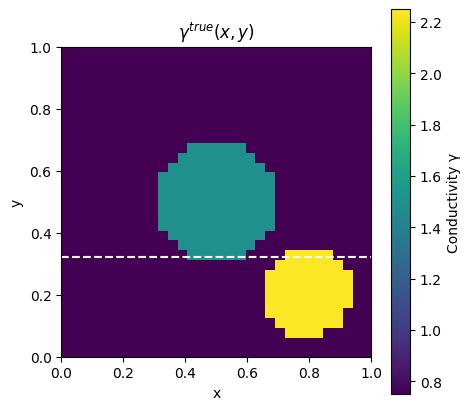

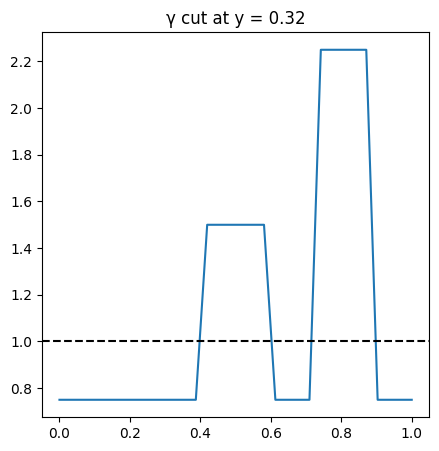

In [56]:
# Load the compressed npz file
case = 'two_inclusions'
data = np.load(f"{saving_path}/dtn_data_{case}.npz")

# See what keys are inside
print("Keys in file:")
for key in data.keys():
    print(key)

gamma_true = data["gamma_true"]          # (N, N) conductivity map
bnd_coords = data["boundary_coords"]     # (num_boundary_points, 2)
u_all = data["induced_potentials"]      # (K, N, N)
f_all = data["boundary_potentials"]      # (K, num_boundary_points)
J_all = data["clean_currents"]           # (K, num_boundary_points)
# J_noisy1 = data["noisy_currents_1pct"]   # same shape, noisy
# J_noisy5 = data["noisy_currents_5pct"]   # same shape, noisy
N = int(data["grid_N"])
K = int(data["num_bcs"])
# bc_names = data['bc_names']
print('Num of BCs:', f_all.shape[0])
print('Points in grid N:', (f_all.shape[1]/4)+1, 'x', (f_all.shape[1]/4)+1)


print(gamma_true.shape)

idx_cut = N//3
gamma_cut = gamma_true[idx_cut,:]
x_cut = np.linspace(0,1,len(gamma_cut))

fig = plt.figure(figsize=(5,5))
plt.imshow(gamma_true, origin='lower', extent=[0,1,0,1], cmap="viridis")
plt.colorbar(label="Conductivity γ")
plt.axhline(x_cut[idx_cut], color='white', linestyle='dashed')
plt.title(r"$\gamma^{true}(x,y)$")
plt.xlabel("x")
plt.ylabel("y")
plt.show()
fig.savefig(f'{saving_path}/ground_truth_gamma.pdf')

fig = plt.figure(figsize=(5,5))

plt.plot(x_cut, gamma_cut)
plt.axhline(1, color='k', linestyle='dashed')
plt.title(rf"γ cut at y = {x_cut[idx_cut]:.2f}")
plt.show()

### Solutions

#### Without derivatives

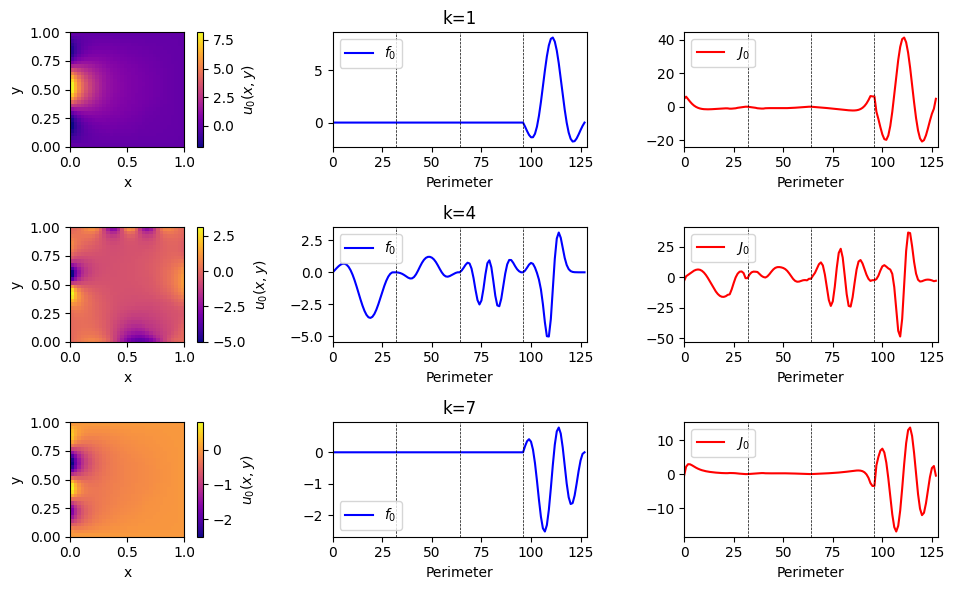

In [46]:
x, y = bnd_coords[:,0], bnd_coords[:,1]

# Identify edges
tol = 1e-12
bottom_idx = np.where(np.abs(y - 0.0) < tol)[0]
top_idx    = np.where(np.abs(y - 1.0) < tol)[0]
left_idx   = np.where(np.abs(x - 0.0) < tol)[0]
right_idx  = np.where(np.abs(x - 1.0) < tol)[0]

# Sort along each edge
bottom_idx = bottom_idx[np.argsort(x[bottom_idx])]         # left→right
top_idx    = top_idx[np.argsort(x[top_idx])][::-1]         # right→left
right_idx  = right_idx[np.argsort(y[right_idx])]           # bottom→top
left_idx   = left_idx[np.argsort(y[left_idx])][::-1]       # top→bottom

# Concatenate perimeter
perimeter_idx = np.concatenate([bottom_idx, right_idx, top_idx, left_idx])

afine = np.arange(4*(N))

k_list=np.arange(K)
# print(k_list)

k_choices = k_list[1::3]

fig,ax = plt.subplots(len(k_choices), 3,figsize=(10,2*len(k_choices)))

for j, k in enumerate(k_choices):
    f_true = f_all[k, perimeter_idx]
    J_true = J_all[k, perimeter_idx]

    u_ex = u_all[k,:,:]


    im1 = ax[j,0].imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
    ax[j,0].set_xlabel("x")
    ax[j,0].set_ylabel("y")
    fig.colorbar(im1, ax=ax[j,0], orientation='vertical', label = r'$u_0(x,y)$')

    ax[j,1].plot(afine, f_true, 'b-', label=r"$f_0$")
    for i in range(1,4):
        ax[j,1].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[j,1].set_xlabel('Perimeter')
    ax[j,1].legend()
    ax[j,1].set_xlim(left=0, right=4*N)
    ax[j,1].set_title(f'k={k}')

    ax[j,2].plot(afine, J_true, 'r-', label=r"$J_0$")
    for i in range(1,4):
        ax[j,2].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[j,2].set_xlabel('Perimeter')
    ax[j,2].legend()
    ax[j,2].set_xlim(left=0, right=4*N)
plt.tight_layout()
    
# plt.suptitle(f'k={k} ; Bottom - Right - Top - Left Boundary')
# fig.savefig(f'{saving_path}/direct_problem_u_f_J.pdf')
plt.show()


### Inspect all

[0 1 2 3 4 5 6 7 8 9]


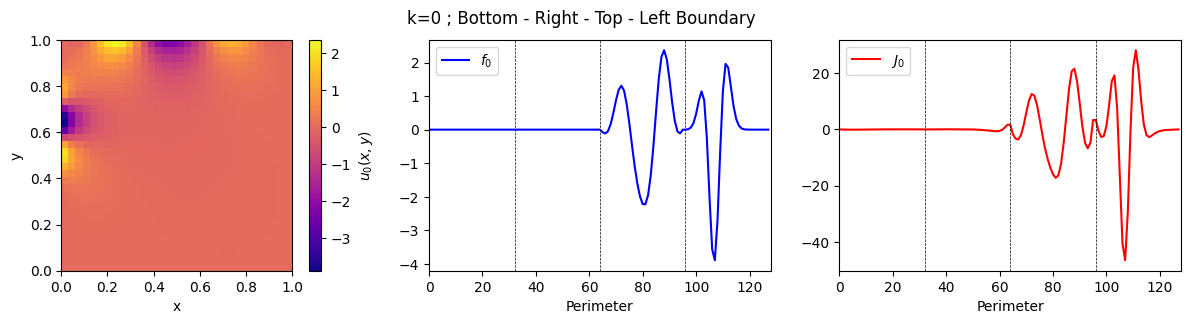

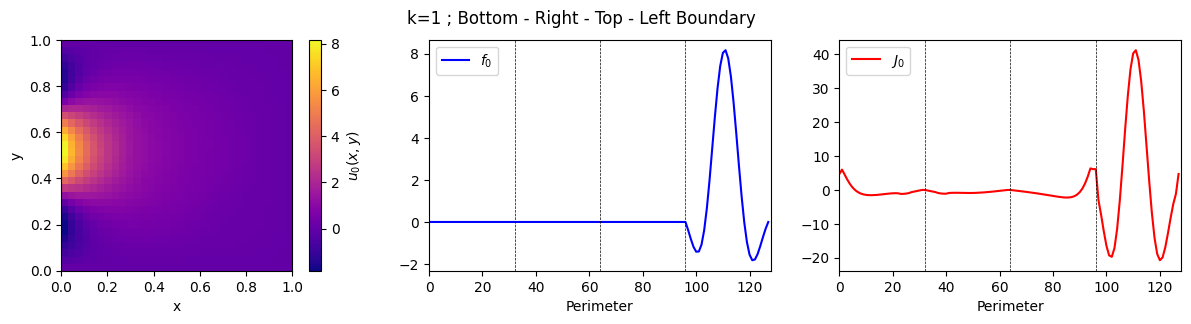

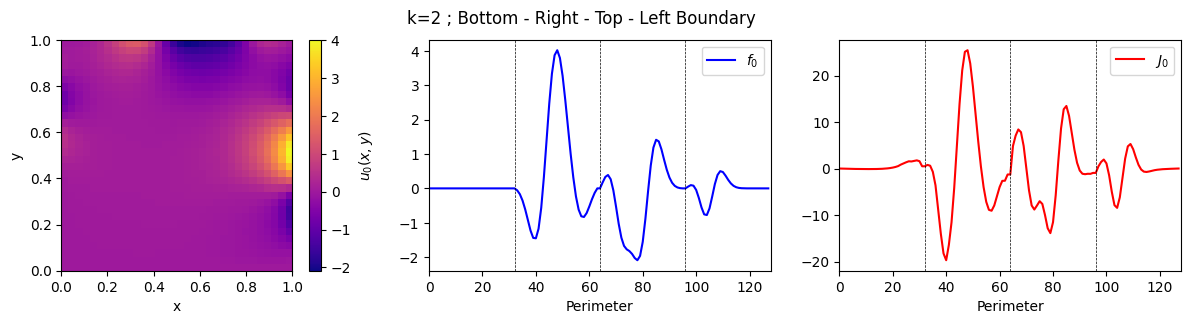

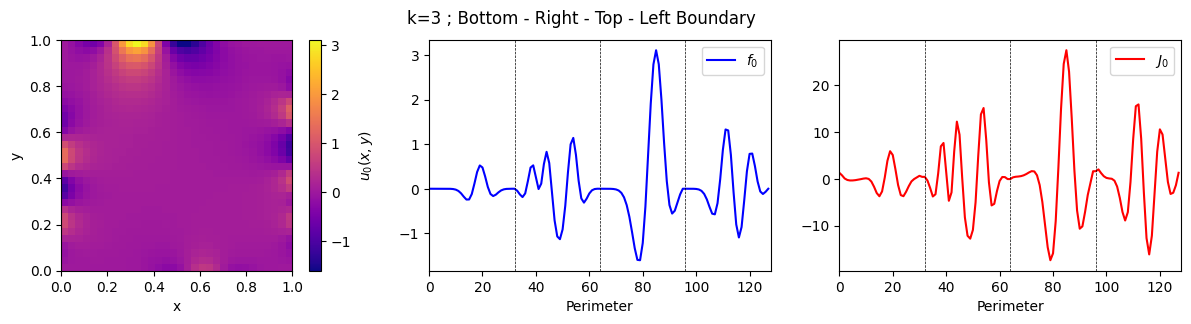

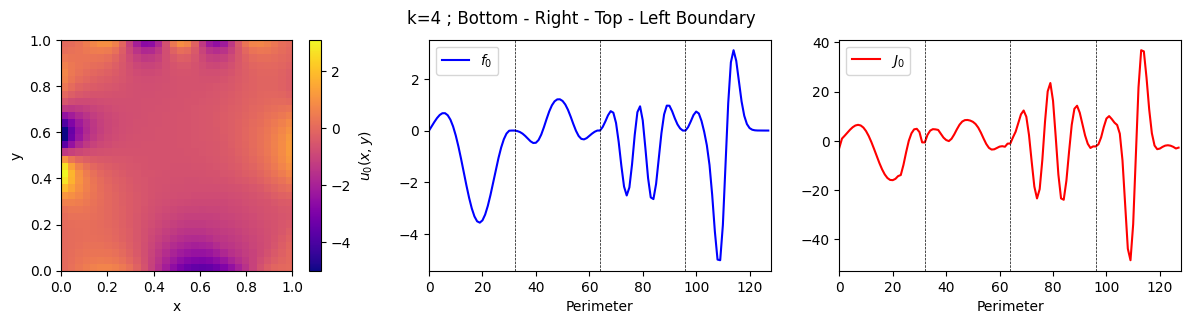

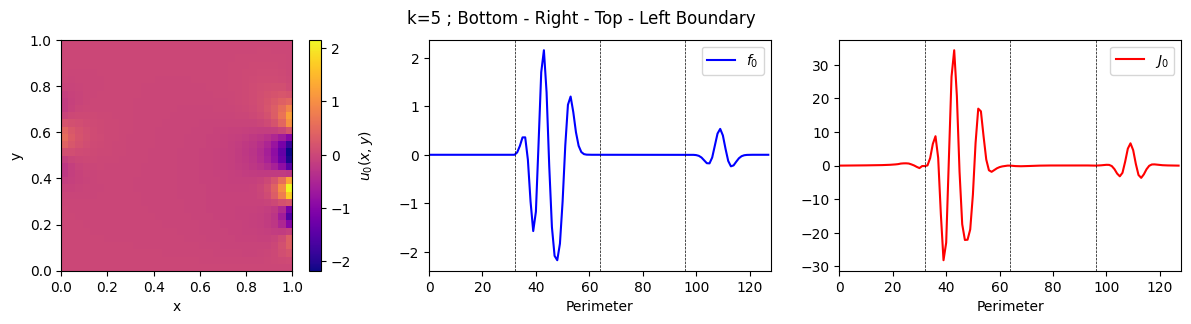

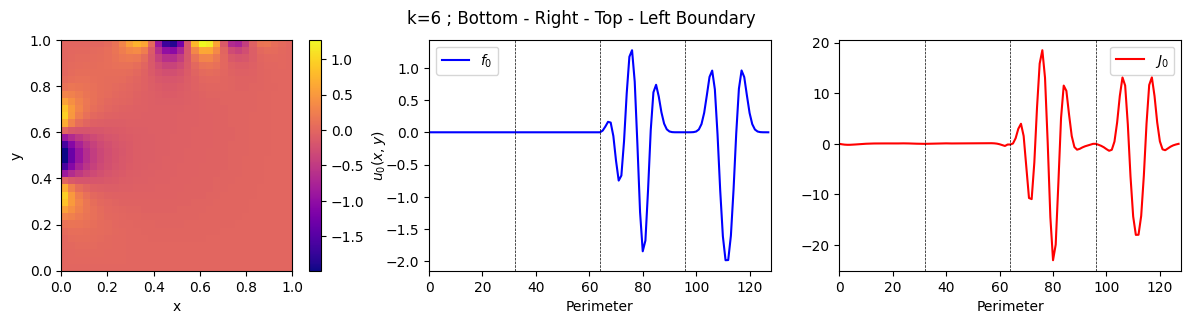

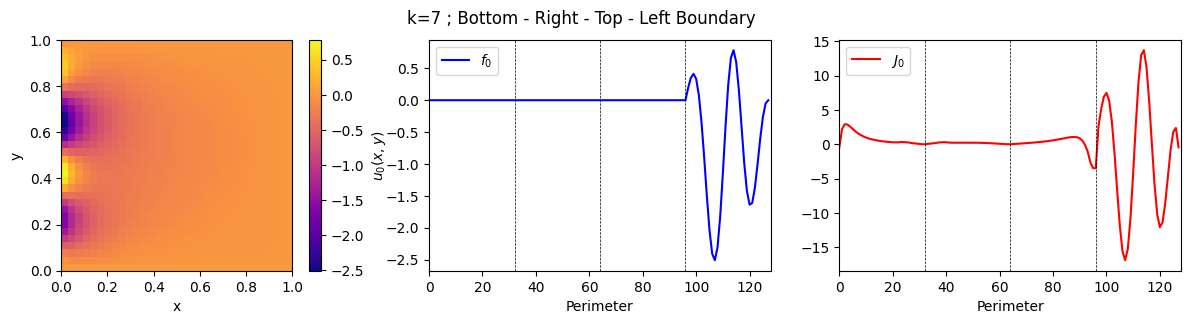

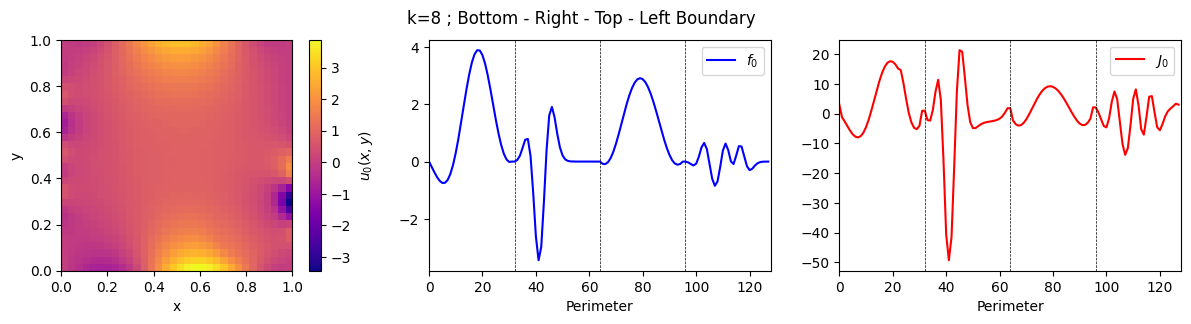

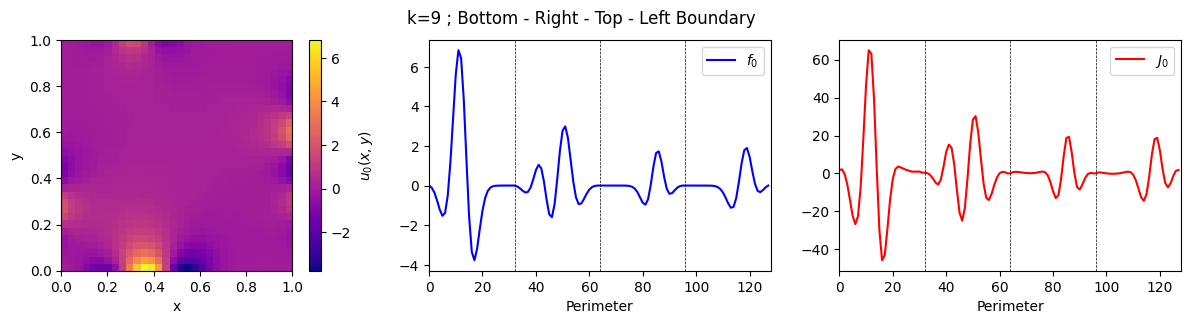

In [47]:
x, y = bnd_coords[:,0], bnd_coords[:,1]

# Identify edges
tol = 1e-12
bottom_idx = np.where(np.abs(y - 0.0) < tol)[0]
top_idx    = np.where(np.abs(y - 1.0) < tol)[0]
left_idx   = np.where(np.abs(x - 0.0) < tol)[0]
right_idx  = np.where(np.abs(x - 1.0) < tol)[0]

# Sort along each edge
bottom_idx = bottom_idx[np.argsort(x[bottom_idx])]         # left→right
top_idx    = top_idx[np.argsort(x[top_idx])][::-1]         # right→left
right_idx  = right_idx[np.argsort(y[right_idx])]           # bottom→top
left_idx   = left_idx[np.argsort(y[left_idx])][::-1]       # top→bottom

# Concatenate perimeter
perimeter_idx = np.concatenate([bottom_idx, right_idx, top_idx, left_idx])

afine = np.arange(4*(N))

k_list=np.arange(K)
print(k_list)

for k in (k_list):

    f_true = f_all[k, perimeter_idx]
    J_true = J_all[k, perimeter_idx]

    u_ex = u_all[k,:,:]

    fig,ax = plt.subplots(1,3,figsize=(15,3))

    im1 = ax[0].imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")
    fig.colorbar(im1, ax=ax[0], orientation='vertical', label = r'$u_0(x,y)$')

    ax[1].plot(afine, f_true, 'b-', label=r"$f_0$")
    for i in range(1,4):
        ax[1].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[1].set_xlabel('Perimeter')
    ax[1].legend()
    ax[1].set_xlim(left=0, right=4*N)

    ax[2].plot(afine, J_true, 'r-', label=r"$J_0$")
    for i in range(1,4):
        ax[2].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[2].set_xlabel('Perimeter')
    ax[2].legend()
    ax[2].set_xlim(left=0, right=4*N)
    
    plt.suptitle(f'k={k} ; Bottom - Right - Top - Left Boundary')
    # fig.savefig(f'{saving_path}/direct_problem_u_f_J.pdf')
    plt.show()


#### With derivatives

[0 1 2 3 4 5 6 7 8 9]


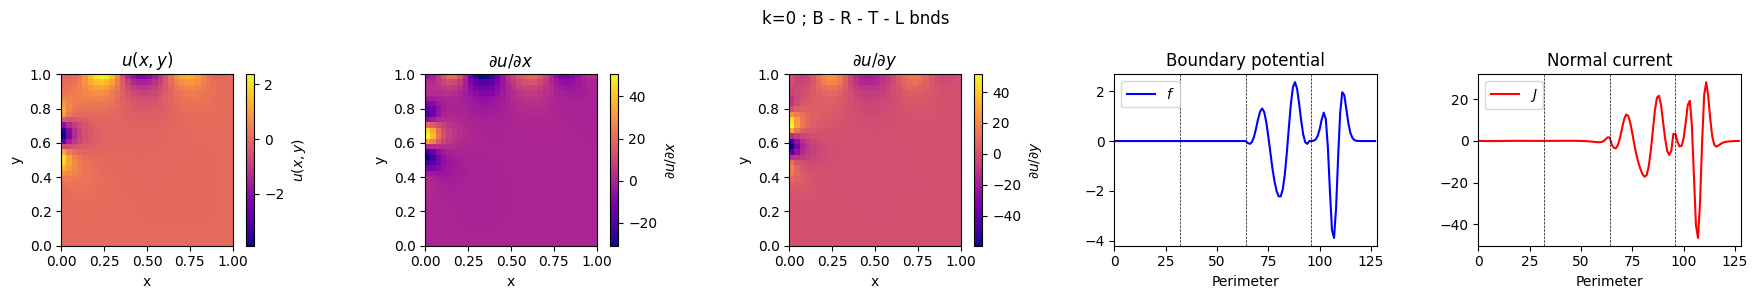

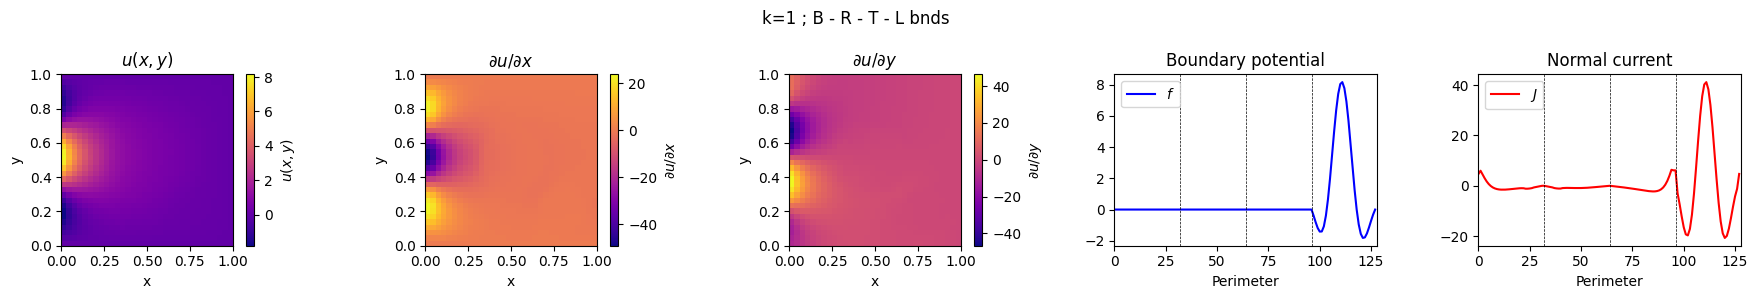

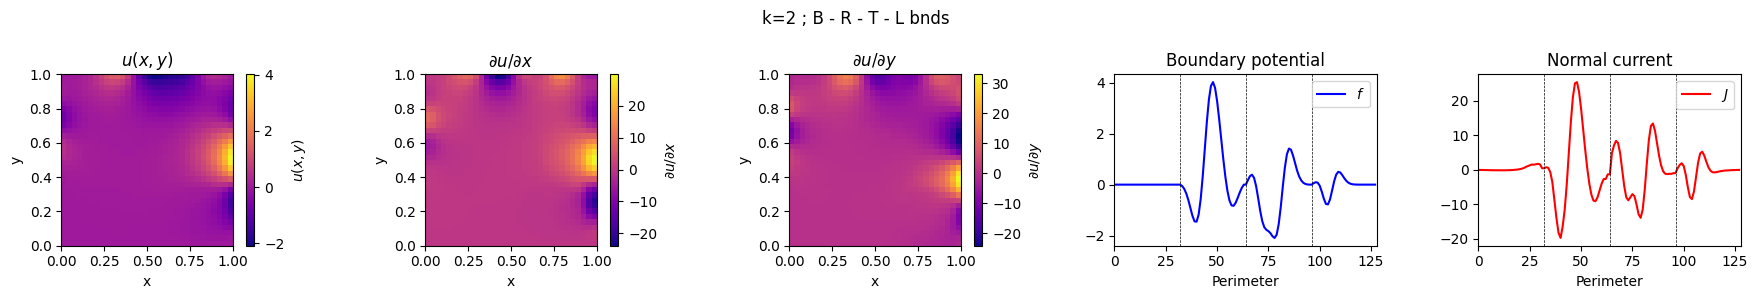

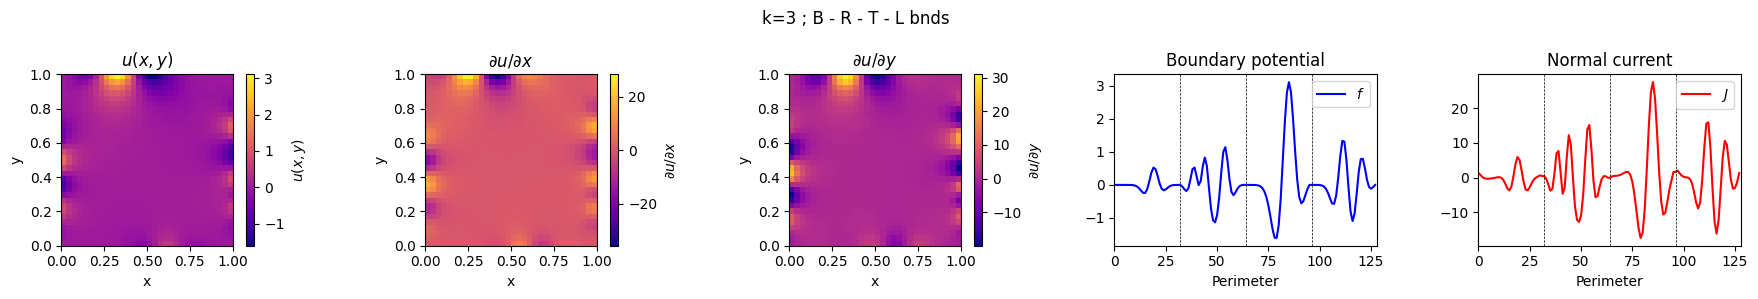

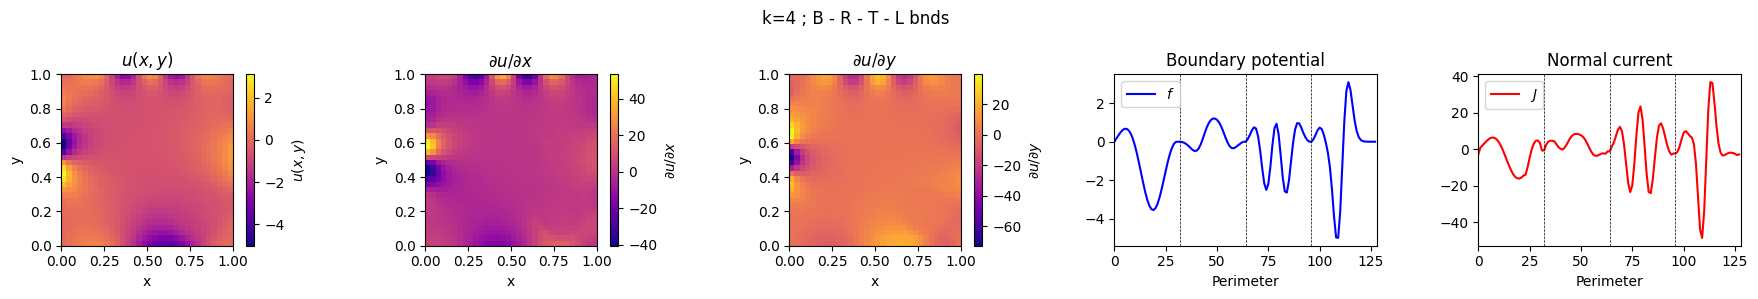

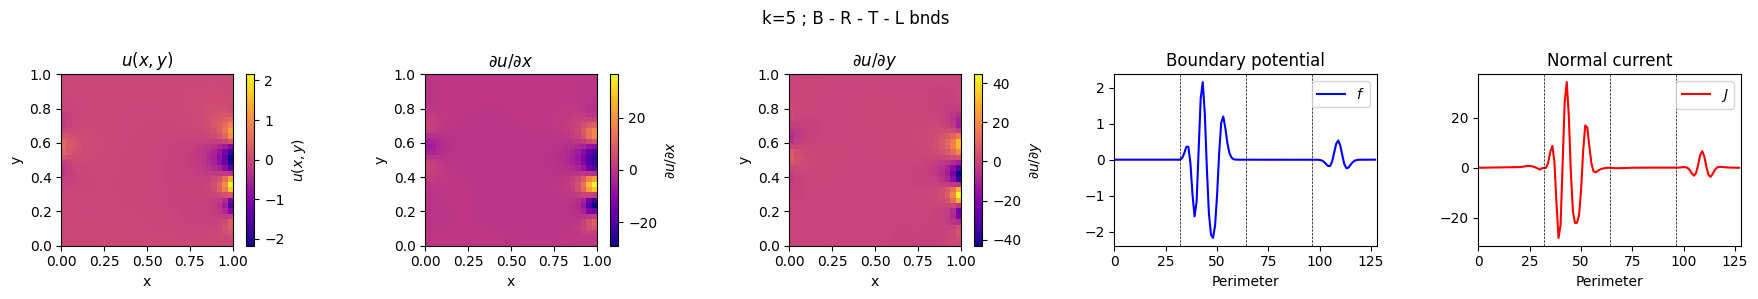

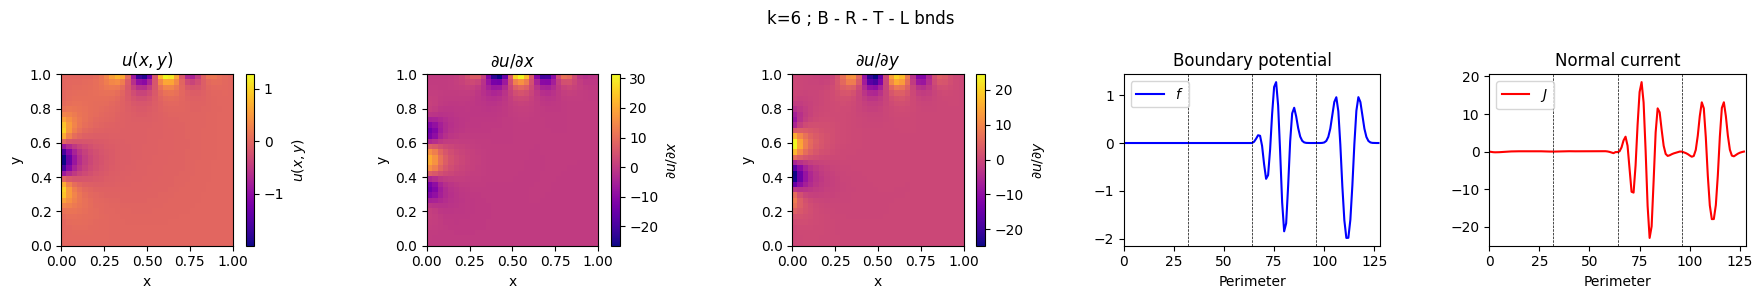

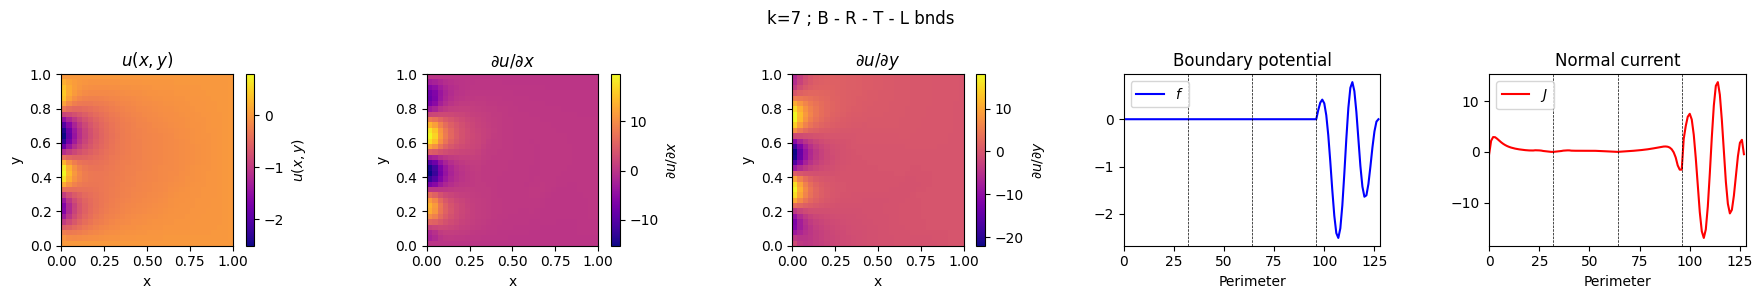

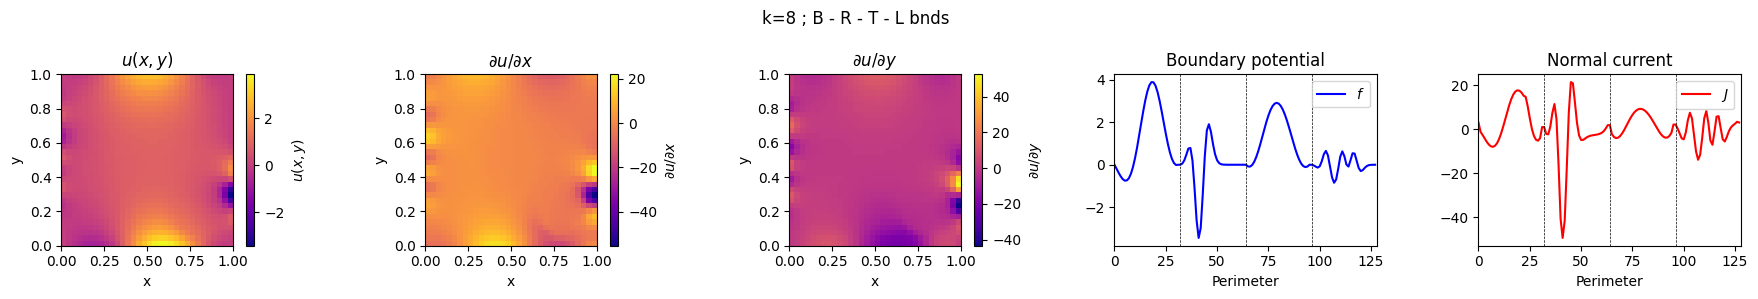

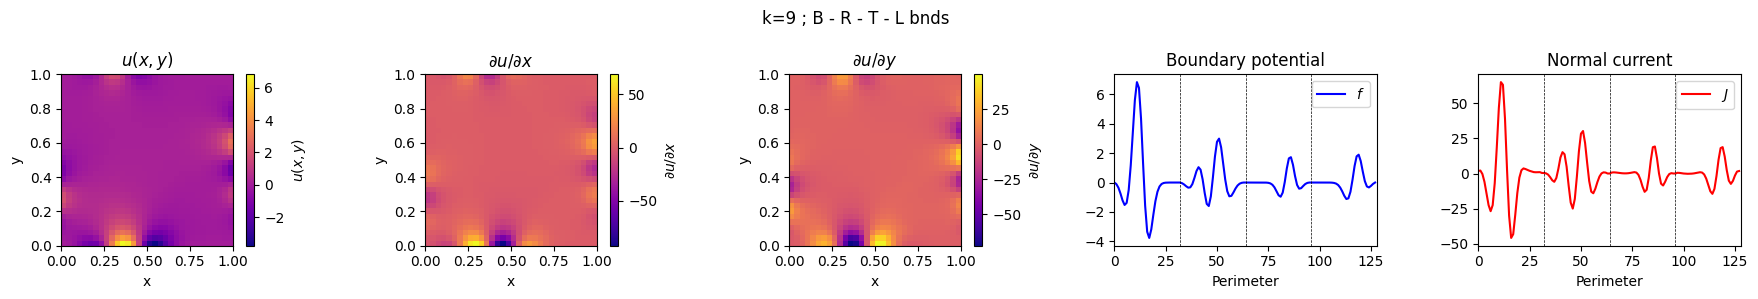

In [48]:
k_list = np.arange(K)
print(k_list)

for k in k_list:

    f_true = f_all[k, perimeter_idx]
    J_true = J_all[k, perimeter_idx]
    u_ex = u_all[k, :, :]

    # === Compute derivatives ===
    dx = 1.0 / (N - 1)
    dy = 1.0 / (N - 1)
    u_y, u_x = np.gradient(u_ex, dy, dx)  # returns (∂u/∂y, ∂u/∂x)

    fig, ax = plt.subplots(1, 5, figsize=(18, 3))

    # === (1) u(x,y) ===
    im0 = ax[0].imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
    fig.colorbar(im0, ax=ax[0], orientation='vertical', label=r'$u(x,y)$')
    ax[0].set_title(r'$u(x,y)$')
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")

    # === (2) ∂u/∂x ===
    im1 = ax[1].imshow(u_x, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
    fig.colorbar(im1, ax=ax[1], orientation='vertical', label=r'$\partial u/\partial x$')
    ax[1].set_title(r'$\partial u/\partial x$')
    ax[1].set_xlabel("x")
    ax[1].set_ylabel("y")

    # === (3) ∂u/∂y ===
    im2 = ax[2].imshow(u_y, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
    fig.colorbar(im2, ax=ax[2], orientation='vertical', label=r'$\partial u/\partial y$')
    ax[2].set_title(r'$\partial u/\partial y$')
    ax[2].set_xlabel("x")
    ax[2].set_ylabel("y")

    # === (4) f vs perimeter ===
    ax[3].plot(afine, f_true, 'b-', label=r"$f$")
    for i in range(1, 4):
        ax[3].axvline(i * N, color='k', linestyle='--', linewidth=0.5)
    ax[3].set_xlabel('Perimeter')
    ax[3].legend()
    ax[3].set_xlim(left=0, right=4 * N)
    ax[3].set_title("Boundary potential")

    # === (5) J vs perimeter ===
    ax[4].plot(afine, J_true, 'r-', label=r"$J$")
    for i in range(1, 4):
        ax[4].axvline(i * N, color='k', linestyle='--', linewidth=0.5)
    ax[4].set_xlabel('Perimeter')
    ax[4].legend()
    ax[4].set_xlim(left=0, right=4 * N)
    ax[4].set_title("Normal current")

    plt.suptitle(f'k={k} ; B - R - T - L bnds')
    plt.tight_layout()
    plt.show()


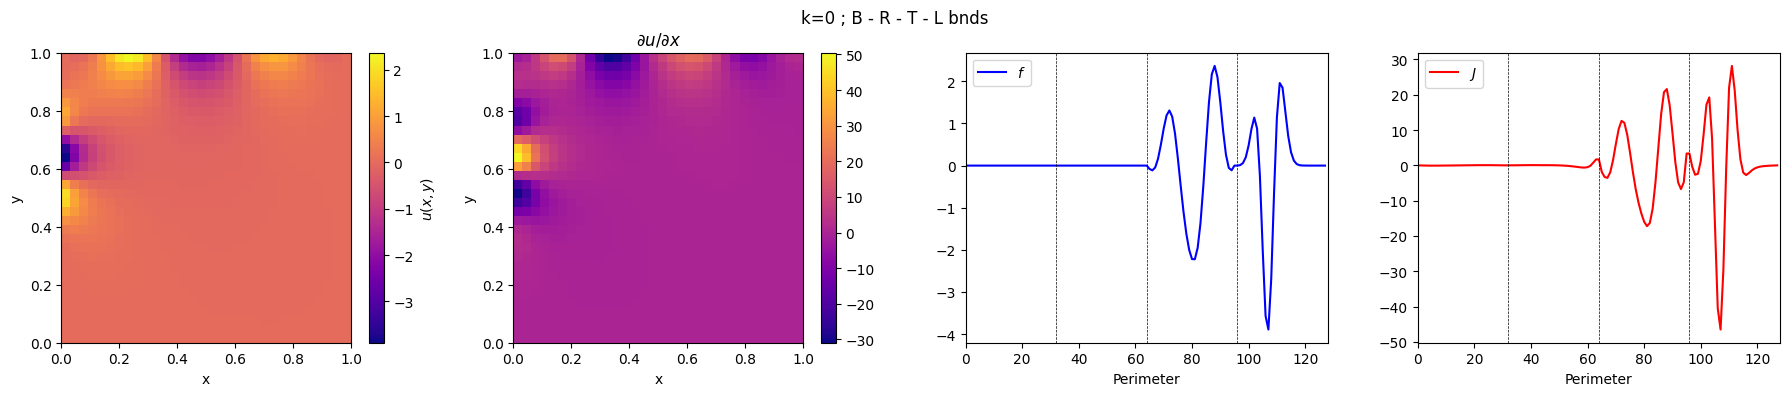

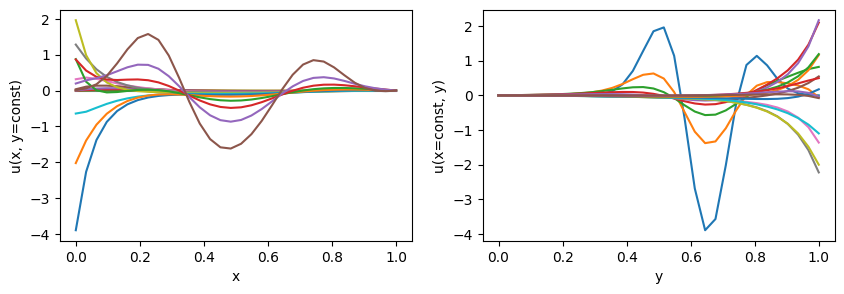

In [49]:
k=0


f_true = f_all[k, perimeter_idx]
J_true = J_all[k, perimeter_idx]
u_ex = u_all[k,:,:]

# === Compute derivatives ===
dx = 1.0 / (N - 1)
dy = 1.0 / (N - 1)
u_x = np.gradient(u_ex, axis=1) / dx   # derivative w.r.t x
u_y = np.gradient(u_ex, axis=0) / dy   # derivative w.r.t y

# u_y, u_x = np.gradient(u_ex, dy, dx)


fig, ax = plt.subplots(1, 4, figsize=(18, 4))

# === (0) Plot u(x,y) ===
im0 = ax[0].imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
fig.colorbar(im0, ax=ax[0], orientation='vertical', label=r'$u(x,y)$')

# === (1) Plot ∂u/∂x and ∂u/∂y side by side ===
# Left half: u_x
im1 = ax[1].imshow(u_x, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
ax[1].set_title(r'$\partial u / \partial x$')
fig.colorbar(im1, ax=ax[1], orientation='vertical')
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")

# (Optional: If you'd prefer quiver instead, uncomment below and remove im1/im2)
# X, Y = np.meshgrid(np.linspace(0, 1, N), np.linspace(0, 1, N))
# ax[1].quiver(X, Y, u_x, u_y)
# ax[1].set_title(r'$\nabla u(x,y)$')

# === (2) Plot f along perimeter ===
ax[2].plot(afine, f_true, 'b-', label=r"$f$")
for i in range(1, 4):
    ax[2].axvline(i * N, color='k', linestyle='--', linewidth=0.5)
ax[2].set_xlabel('Perimeter')
ax[2].legend()
ax[2].set_xlim(left=0, right=4 * N)

# === (3) Plot J along perimeter ===
ax[3].plot(afine, J_true, 'r-', label=r"$J$")
for i in range(1, 4):
    ax[3].axvline(i * N, color='k', linestyle='--', linewidth=0.5)
ax[3].set_xlabel('Perimeter')
ax[3].legend()
ax[3].set_xlim(left=0, right=4 * N)

plt.suptitle(f'k={k} ; B - R - T - L bnds')
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(1,2, figsize=(10,3))

for i in np.arange(0,N,2):
    cut_indx = i
    ax[0].plot(np.linspace(0,1,len(u_ex[:,0])), u_ex[cut_indx,:])
    ax[1].plot(np.linspace(0,1,len(u_ex[:,0])), u_ex[:,cut_indx])
    ax[1].set_xlabel('y')
    ax[1].set_ylabel('u(x=const, y)')
    ax[0].set_xlabel('x')
    ax[0].set_ylabel('u(x, y=const)')

plt.show()

[0 1 2 3 4 5 6 7 8 9]


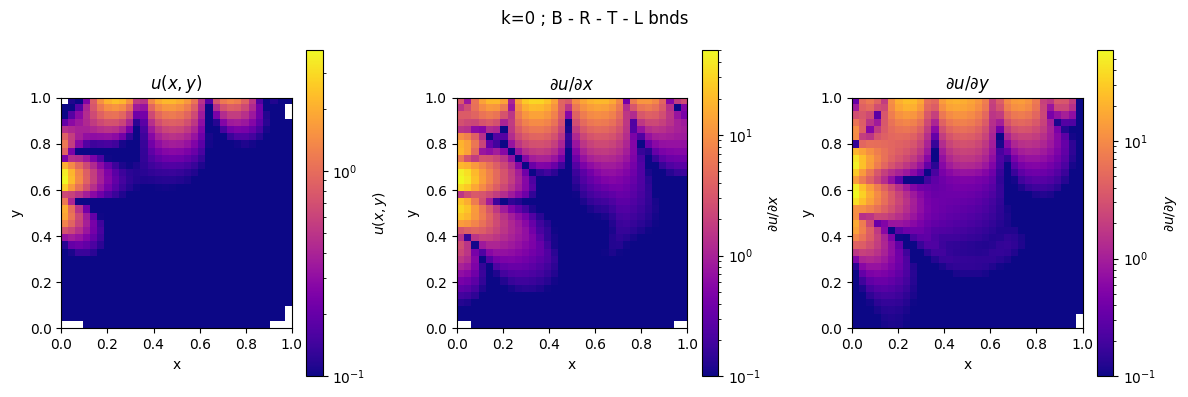

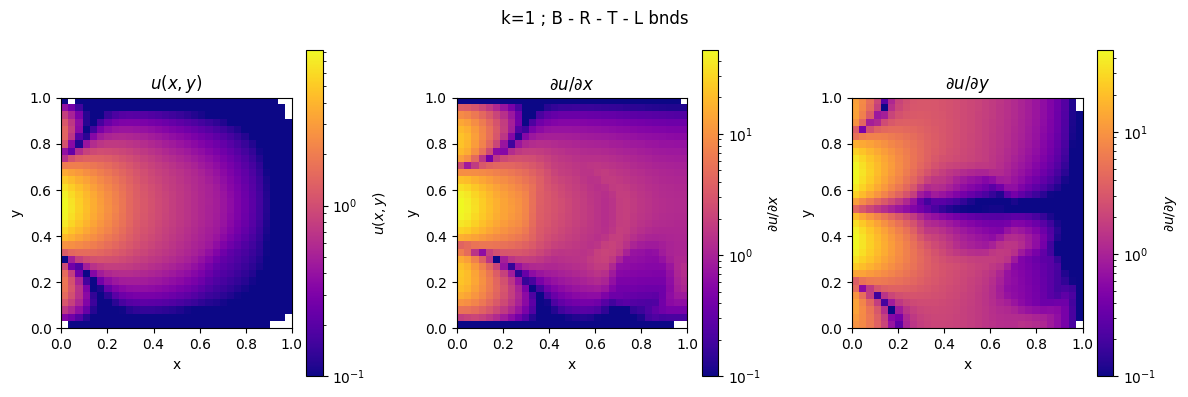

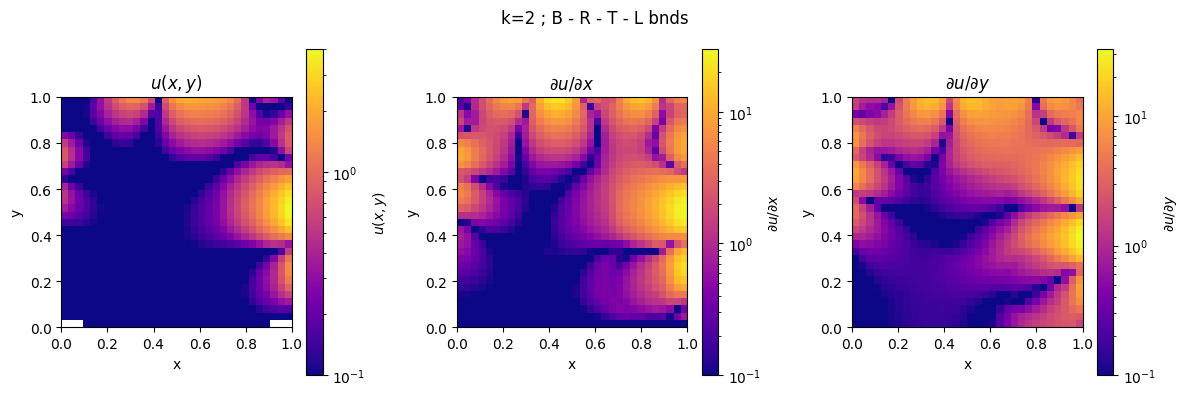

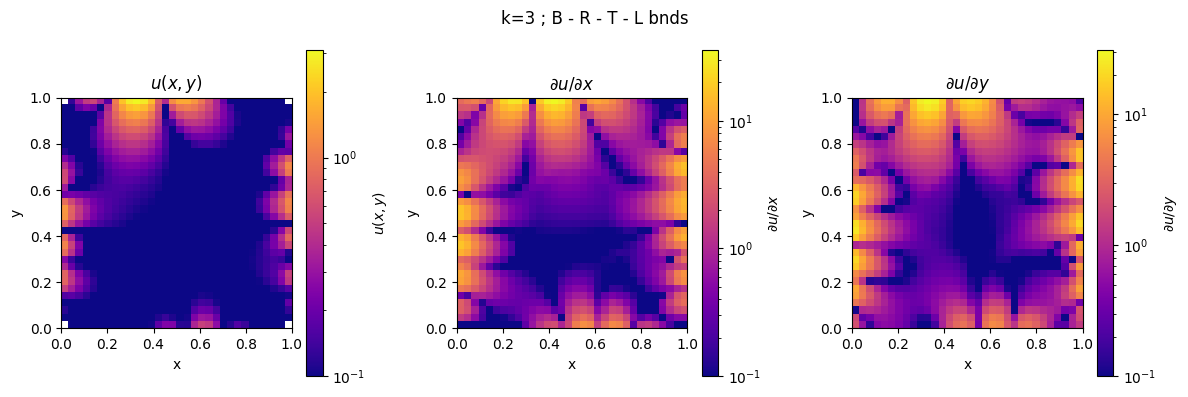

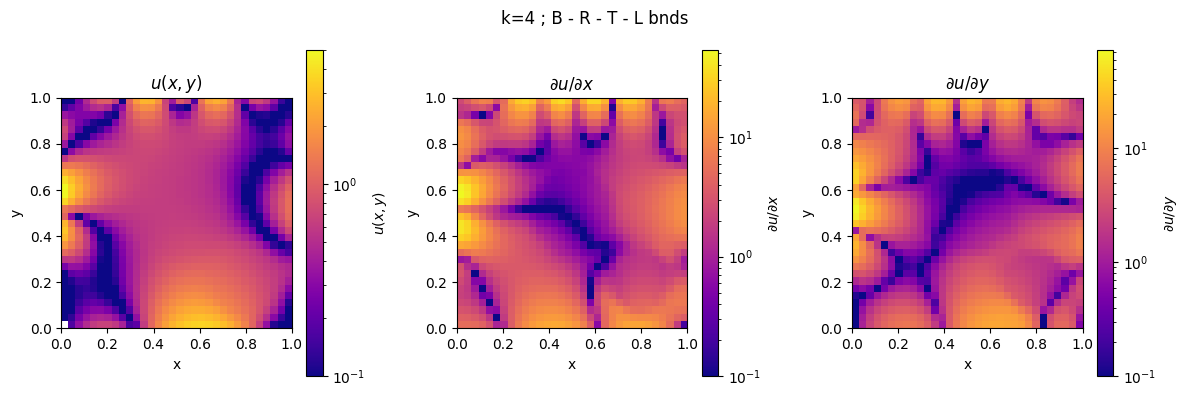

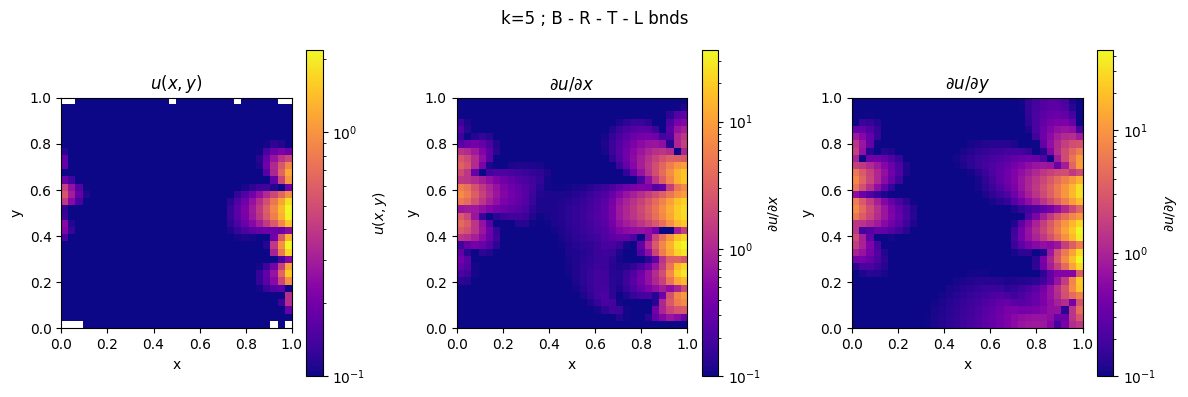

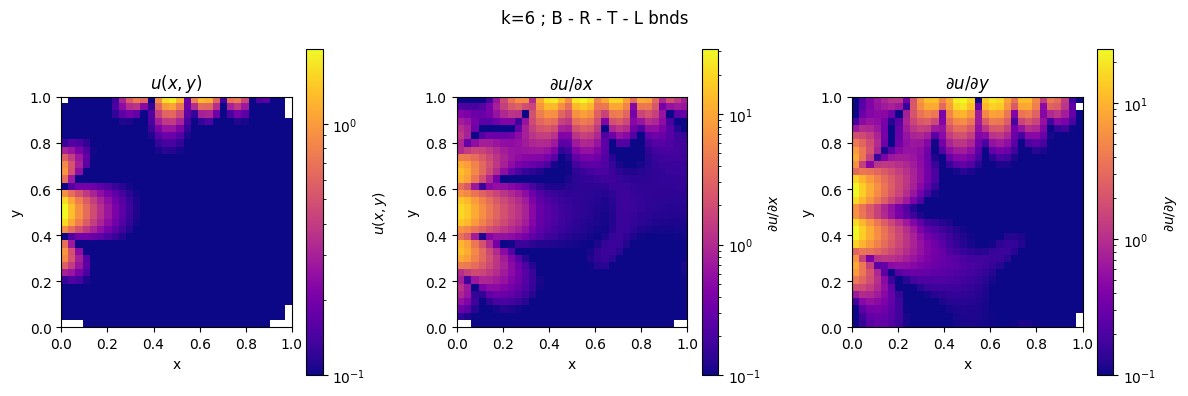

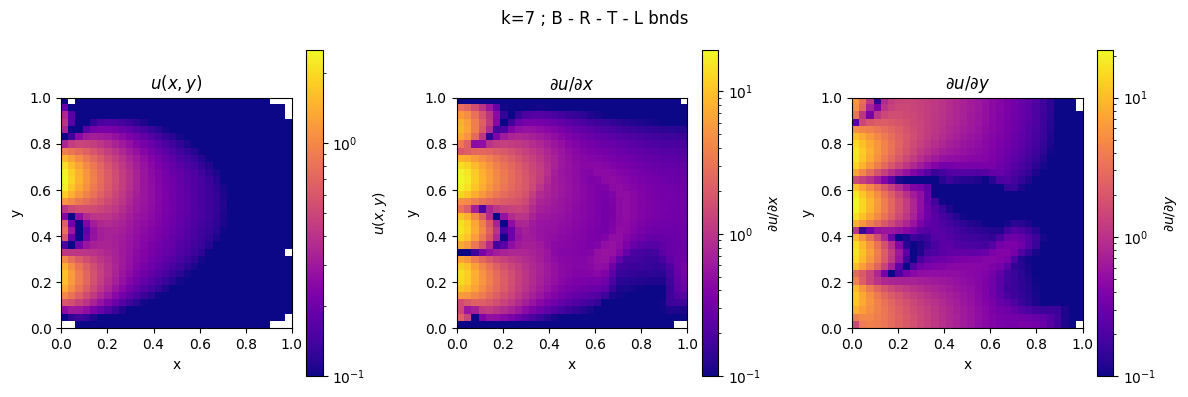

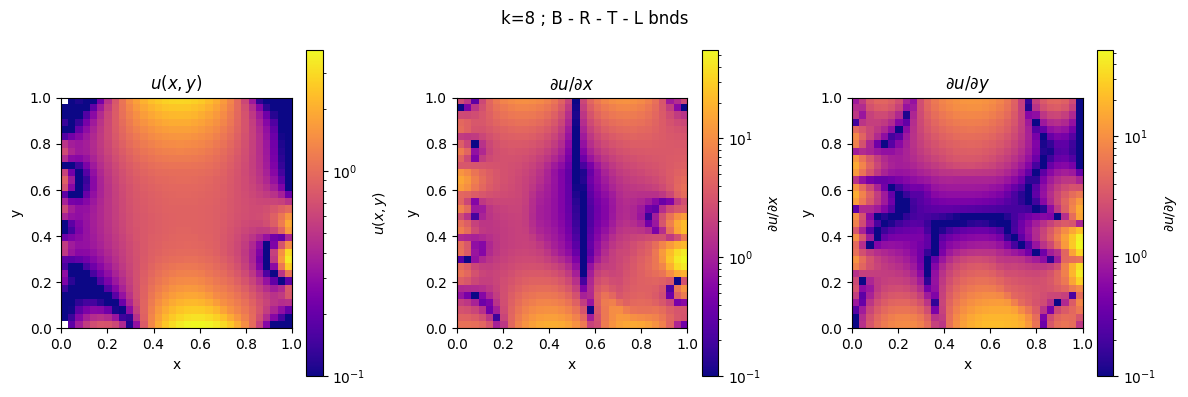

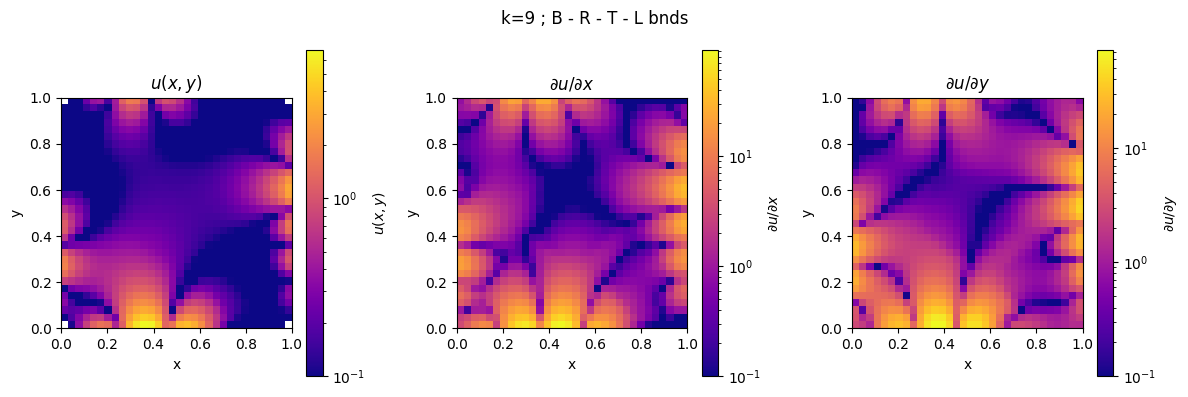

In [50]:
from matplotlib import colors


k_list = np.arange(K)
print(k_list)

for k in k_list:
    #name = bc_names[k]

    f_true = f_all[k, perimeter_idx]
    J_true = J_all[k, perimeter_idx]
    u_ex = u_all[k, :, :]

    # === Compute derivatives ===
    dx = 1.0 / (N - 1)
    dy = 1.0 / (N - 1)
    u_y, u_x = np.gradient(u_ex, dy, dx)  # returns (∂u/∂y, ∂u/∂x)

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))

    # === (1) u(x,y) ===
    im0 = ax[0].imshow(np.abs(u_ex), origin='lower', extent=[0, 1, 0, 1], cmap='plasma',  norm=colors.LogNorm(vmin=1e-1, vmax=np.abs(u_ex).max()))
    fig.colorbar(im0, ax=ax[0], orientation='vertical', label=r'$u(x,y)$')
    ax[0].set_title(r'$u(x,y)$')
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")

    # === (2) ∂u/∂x ===
    im1 = ax[1].imshow(np.abs(u_x), origin='lower', extent=[0, 1, 0, 1], cmap='plasma', norm=colors.LogNorm(vmin=1e-1, vmax=np.abs(u_x).max()))
    fig.colorbar(im1, ax=ax[1], orientation='vertical', label=r'$\partial u/\partial x$',
)
    ax[1].set_title(r'$\partial u/\partial x$')
    ax[1].set_xlabel("x")
    ax[1].set_ylabel("y")

    # === (3) ∂u/∂y ===
    im2 = ax[2].imshow(np.abs(u_y), origin='lower', extent=[0, 1, 0, 1], cmap='plasma', norm=colors.LogNorm(vmin=1e-1, vmax=np.abs(u_y).max()))
    fig.colorbar(im2, ax=ax[2], orientation='vertical', label=r'$\partial u/\partial y$')
    ax[2].set_title(r'$\partial u/\partial y$')
    ax[2].set_xlabel("x")
    ax[2].set_ylabel("y")

    plt.suptitle(f'k={k} ; B - R - T - L bnds')
    plt.tight_layout()
    plt.show()


### Check features in the central region

[0 1 2 3 4 5 6 7 8 9]


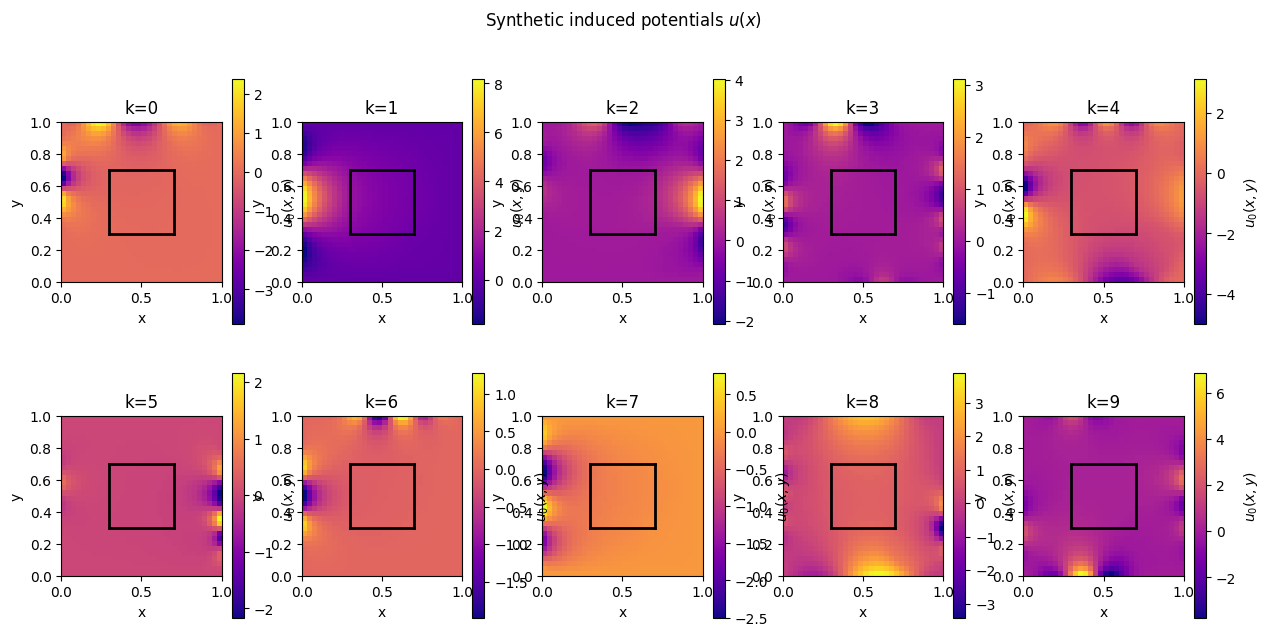

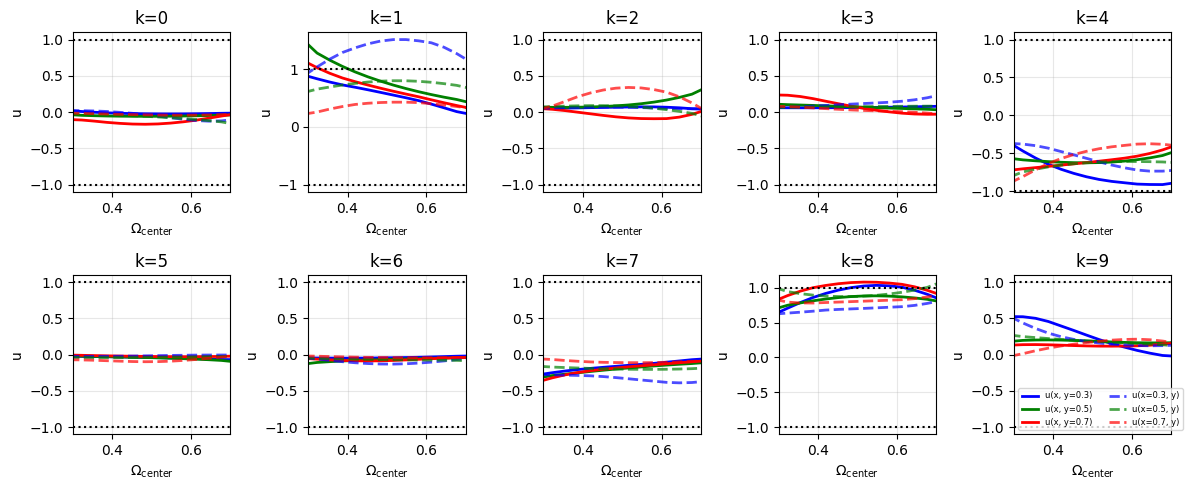

In [51]:
k_list=np.arange(K)
print(k_list)

fig,ax = plt.subplots(2,5,figsize=(15,7))

j=-1
FLAG=True
for k in (k_list):

    if k < 5:
        i=0
    else:
        i=1
        if FLAG:
            j=-1
            FLAG = False

    j+=1

    f_true = f_all[k, perimeter_idx]
    J_true = J_all[k, perimeter_idx]

    u_ex = u_all[k,:,:]


    im1 = ax[i,j].imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
    ax[i,j].set_xlabel("x")
    ax[i,j].set_ylabel("y")
    # Add box between 0.25 and 0.75
    box_coords = [0.3, 0.7]
    ax[i,j].plot([box_coords[0], box_coords[1]], [box_coords[0], box_coords[0]], 'k-', linewidth=2)  # Bottom
    ax[i,j].plot([box_coords[1], box_coords[1]], [box_coords[0], box_coords[1]], 'k-', linewidth=2)  # Right
    ax[i,j].plot([box_coords[1], box_coords[0]], [box_coords[1], box_coords[1]], 'k-', linewidth=2)  # Top
    ax[i,j].plot([box_coords[0], box_coords[0]], [box_coords[1], box_coords[0]], 'k-', linewidth=2)  # Left
    ax[i,j].set_title(f'k={k}')
    fig.colorbar(im1, ax=ax[i,j], orientation='vertical', label = r'$u_0(x,y)$')


plt.suptitle(r'Synthetic induced potentials $u(x)$')
fig.savefig(f'{saving_path}/direct_problem_u_f_J_with_boxes.pdf')
plt.show()


 ################################

fig, ax = plt.subplots(2, 5, figsize=(12, 5))

# Define the box boundaries
box_x = [0.3, 0.7]
box_y = [0.3, 0.7]

# Profiles along x (at constant y)
y_values = [0.3, 0.5, 0.7]  # bottom, center, top of box
y_labels = ['bottom', 'center', 'top']

# Profiles along y (at constant x)
x_values = [0.3, 0.5, 0.7]  # left, center, right of box
x_labels = ['left', 'center', 'right']

colors = ['blue', 'green', 'red']

j = -1
FLAG = True
for k in k_list:
    
    if k < 5:
        i = 0
    else:
        i = 1
        if FLAG:
            j = -1
            FLAG = False
    
    j += 1
    
    u_ex = u_all[k, :, :]
    
    # Get grid coordinates (assuming uniform grid from 0 to 1)
    N_grid = u_ex.shape[0]
    x_grid = np.linspace(0, 1, N_grid)
    y_grid = np.linspace(0, 1, N_grid)
    
    # Find indices corresponding to box ranges
    x_box_idx_start = np.argmin(np.abs(x_grid - box_x[0]))
    x_box_idx_end = np.argmin(np.abs(x_grid - box_x[1]))
    x_box_range = x_grid[x_box_idx_start:x_box_idx_end+1]
    
    y_box_idx_start = np.argmin(np.abs(y_grid - box_y[0]))
    y_box_idx_end = np.argmin(np.abs(y_grid - box_y[1]))
    y_box_range = y_grid[y_box_idx_start:y_box_idx_end+1]
    
    # Plot profiles along x (at constant y) - solid lines
    for y_val, y_label, color in zip(y_values, y_labels, colors):
        y_idx = np.argmin(np.abs(y_grid - y_val))
        u_profile = u_ex[y_idx, x_box_idx_start:x_box_idx_end+1]
        ax[i, j].plot(x_box_range, u_profile, '-', color=color, 
                     label=f'u(x, y={y_val:.1f})', linewidth=2, markersize=4)
    
    # Plot profiles along y (at constant x) - dashed lines
    for x_val, x_label, color in zip(x_values, x_labels, colors):
        x_idx = np.argmin(np.abs(x_grid - x_val))
        u_profile = u_ex[y_box_idx_start:y_box_idx_end+1, x_idx]
        ax[i, j].plot(y_box_range, u_profile, '--', color=color, 
                     label=f'u(x={x_val:.1f}, y)', linewidth=2, markersize=4, alpha=0.7)
    
    ax[i,j].axhline(1,color = 'k', linestyle = 'dotted')
    ax[i,j].axhline(-1,color = 'k', linestyle = 'dotted')

    ax[i, j].set_xlabel(r"$\Omega_\text{center}$")
    ax[i, j].set_ylabel("u")
    ax[i, j].set_xlim(box_x[0], box_x[1])
    ax[i, j].grid(True, alpha=0.3)
    # ax[i, j].legend(fontsize=6, loc='best', ncol=2)
    ax[i, j].set_title(f'k={k}')
plt.legend(fontsize=6, loc='best', ncol=2)
# plt.suptitle('u profiles in box [0.3, 0.7]² | Solid: u(x,y=const) | Dashed: u(x=const,y)')
plt.tight_layout()
fig.savefig(f'{saving_path}/u_profiles_box_both_directions.pdf')
plt.show()